## Limpeza e tratamento dos dados.


In [12]:
from pathlib import Path
import html
import re
import unicodedata

import pandas as pd

# Caminhos relativos à raiz do projeto.
RAW_PATH = Path("data/raw/comments.csv")
PROCESSED_PATH = Path("data/processed/comments_clean.csv")

URL_RE = re.compile(r"(?:https?://|www\.)\S+", flags=re.IGNORECASE)
HASHTAG_RE = re.compile(r"(?<!\w)#([\wÀ-ÿ]+)", flags=re.UNICODE)
MENTION_RE = re.compile(r"(?<!\w)@([\wÀ-ÿ.-]+)", flags=re.UNICODE)


def extract_emojis(text: str) -> list[str]:
    """Extrai símbolos/emoji antes que a limpeza os remova."""
    return [char for char in text if unicodedata.category(char) in {"So", "Sk"}]


def clean_text(value: object) -> str:
    """Normaliza texto para análise, sem modificar a coluna original."""
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKC", html.unescape(str(value)))
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = HASHTAG_RE.sub(r" \1 ", text)  # mantém a palavra da hashtag
    text = "".join(" " if unicodedata.category(char) in {"So", "Sk"} else char for char in text)
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = text.replace("_", " ").casefold()
    return re.sub(r"\s+", " ", text).strip()


if not RAW_PATH.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {RAW_PATH.resolve()}")

comments = pd.read_csv(RAW_PATH, dtype={"comment_id": "string", "video_id": "string", "match_id": "string"})
comments_clean = comments.rename(columns={"text": "text_original", "period": "video_period"}).copy()
original = comments_clean["text_original"].fillna("").astype(str)

# Informações potencialmente úteis são preservadas em colunas próprias.
comments_clean["urls"] = original.map(lambda text: URL_RE.findall(text))
comments_clean["hashtags"] = original.map(lambda text: HASHTAG_RE.findall(text))
comments_clean["mentions"] = original.map(lambda text: MENTION_RE.findall(text))
comments_clean["emojis"] = original.map(extract_emojis)
comments_clean["emoji_count"] = comments_clean["emojis"].map(len)
comments_clean["text_clean"] = comments_clean["text_original"].map(clean_text)
comments_clean["is_empty_after_clean"] = comments_clean["text_clean"].eq("")
comments_clean["is_duplicate_id"] = comments_clean.duplicated("comment_id", keep=False)

for column in ("published_at", "updated_at"):
    comments_clean[column] = pd.to_datetime(comments_clean[column], errors="coerce", utc=True)

# O período analítico pertence ao comentário, não ao vídeo.
from config.settings import MATCH_DURATION_MINUTES, PRE_GAME_DAYS, POST_GAME_DAYS
match_times = pd.read_csv("data/raw/matches.csv", usecols=["match_id", "match_datetime"], dtype={"match_id": "string"})
match_times["kickoff_at"] = pd.to_datetime(match_times["match_datetime"], errors="coerce", utc=True)
kickoff_by_match = match_times.set_index("match_id")["kickoff_at"]
comments_clean["kickoff_at"] = comments_clean["match_id"].map(kickoff_by_match)
comments_clean["estimated_match_end_at"] = comments_clean["kickoff_at"] + pd.to_timedelta(MATCH_DURATION_MINUTES, unit="m")
comments_clean["hours_from_kickoff"] = (comments_clean["published_at"] - comments_clean["kickoff_at"]).dt.total_seconds() / 3600
comments_clean["comment_period"] = pd.Series(pd.NA, index=comments_clean.index, dtype="string")
comments_clean.loc[comments_clean["published_at"] < comments_clean["kickoff_at"], "comment_period"] = "pre_game"
comments_clean.loc[comments_clean["published_at"].between(comments_clean["kickoff_at"], comments_clean["estimated_match_end_at"], inclusive="both"), "comment_period"] = "during_game"
comments_clean.loc[comments_clean["published_at"] > comments_clean["estimated_match_end_at"], "comment_period"] = "post_game"
comments_clean["within_comment_window"] = comments_clean["published_at"].between(
    comments_clean["kickoff_at"] - pd.to_timedelta(PRE_GAME_DAYS, unit="D"),
    comments_clean["estimated_match_end_at"] + pd.to_timedelta(POST_GAME_DAYS, unit="D"), inclusive="both",
)
for column in ("like_count", "reply_count"):
    comments_clean[column] = pd.to_numeric(comments_clean[column], errors="coerce").fillna(0).astype("Int64")
comments_clean["is_reply"] = comments_clean["is_reply"].astype("string").str.lower().map({"true": True, "false": False}).astype("boolean")

PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
comments_clean.to_csv(PROCESSED_PATH, index=False)

print(f"Registros tratados: {len(comments_clean):,}")
print(f"IDs duplicados: {comments_clean['is_duplicate_id'].sum():,}")
print(f"Textos vazios após limpeza: {comments_clean['is_empty_after_clean'].sum():,}")
print(f"Arquivo salvo em: {PROCESSED_PATH}")
comments_clean[["text_original", "text_clean", "hashtags", "mentions", "emojis"]].head()


Registros tratados: 58,910
IDs duplicados: 0
Textos vazios após limpeza: 1,294
Arquivo salvo em: data/processed/comments_clean.csv


,text_original,text_clean,hashtags,mentions,emojis
0,Chupa galo aqui e Vila Belmiro peixaõ estou co...,chupa galo aqui e vila belmiro peixaõ estou co...,[],[],[]
1,Crizeiro classificado Zica santista fanatico t...,crizeiro classificado zica santista fanatico t...,[],[],[]
2,Passa o cruzeiro galo eliminado chupa galo,passa o cruzeiro galo eliminado chupa galo,[],[],[]
3,Sou santista mais sou crizeiro melgor que galo,sou santista mais sou crizeiro melgor que galo,[],[],[]
4,Cruzeiro tá ganhando,cruzeiro tá ganhando,[],[],[]


## Validação da qualidade dos dados

Esta etapa investiga os textos vazios sem removê-los e verifica IDs, relacionamentos entre respostas e valores categóricos.

In [13]:
videos = pd.read_csv("data/raw/videos.csv", dtype="string")
matches = pd.read_csv("data/raw/matches.csv", dtype="string")

empty = comments_clean.loc[comments_clean["is_empty_after_clean"]].copy()
empty_diagnosis = pd.Series({
    "total_vazios": len(empty),
    "com_emoji": empty["emoji_count"].gt(0).sum(),
    "com_url": empty["urls"].map(len).gt(0).sum(),
    "com_mencao": empty["mentions"].map(len).gt(0).sum(),
    "texto_original_ausente": empty["text_original"].isna().sum(),
}, name="quantidade").to_frame()

top_level_ids = set(comments_clean.loc[~comments_clean["is_reply"].fillna(False), "comment_id"].dropna())
reply_parent_ids = comments_clean.loc[comments_clean["is_reply"].fillna(False), "parent_comment_id"].dropna()

quality_report = pd.Series({
    "registros": len(comments_clean),
    "ids_duplicados": comments_clean["comment_id"].duplicated().sum(),
    "ids_essenciais_ausentes": comments_clean[["comment_id", "video_id", "match_id"]].isna().any(axis=1).sum(),
    "videos_inexistentes": (~comments_clean["video_id"].isin(videos["video_id"])).sum(),
    "partidas_inexistentes": (~comments_clean["match_id"].isin(matches["match_id"])).sum(),
    "respostas_sem_comentario_pai": (~reply_parent_ids.isin(top_level_ids)).sum(),
    "periodos_do_video_invalidos": (~comments_clean["video_period"].isin(["pre_game", "post_game"])).sum(),
    "periodos_do_comentario_invalidos": (~comments_clean["comment_period"].isin(["pre_game", "during_game", "post_game"])).sum(),
    "comentarios_fora_da_janela": (~comments_clean["within_comment_window"]).sum(),
    "datas_publicacao_invalidas": comments_clean["published_at"].isna().sum(),
    "textos_vazios_apos_limpeza": comments_clean["is_empty_after_clean"].sum(),
}, name="quantidade").to_frame()

display(quality_report)
display(empty_diagnosis)
display(pd.crosstab(comments_clean["video_period"], comments_clean["comment_period"], margins=True).rename_axis("período do vídeo"))
display(empty[["text_original", "urls", "mentions", "emojis", "video_period", "comment_period"]].head(20))


,quantidade
registros,58910
ids_duplicados,0
ids_essenciais_ausentes,0
videos_inexistentes,0
partidas_inexistentes,0
respostas_sem_comentario_pai,0
periodos_do_video_invalidos,0
periodos_do_comentario_invalidos,0
comentarios_fora_da_janela,7501
datas_publicacao_invalidas,0


,quantidade
total_vazios,1294
com_emoji,1100
com_url,4
com_mencao,310
texto_original_ausente,4


comment_period,during_game,post_game,pre_game,All
período do vídeo,,,,
post_game,185,57169,0,57354
pre_game,101,1001,454,1556
All,286,58170,454,58910


,text_original,urls,mentions,emojis,video_period,comment_period
241,🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮,[],[],"[🎮, 🎮, 🎮, 🎮, 🎮, 🎮, 🎮, 🎮, 🎮, 🎮, 🎮, 🎮, 🎮, 🎮, 🎮, ...",post_game,post_game
419,😱😱😱😱,[],[],"[😱, 😱, 😱, 😱]",post_game,post_game
509,🐓💪💪💪💪💪,[],[],"[🐓, 💪, 💪, 💪, 💪, 💪]",post_game,post_game
887,🐔😮,[],[],"[🐔, 😮]",post_game,post_game
929,😂😂😂😂😂😂😂😂😂,[],[],"[😂, 😂, 😂, 😂, 😂, 😂, 😂, 😂, 😂]",post_game,post_game
1018,😂😂😂😂,[],[],"[😂, 😂, 😂, 😂]",post_game,post_game
1086,🚔🚔🚔🚔🚔,[],[],"[🚔, 🚔, 🚔, 🚔, 🚔]",post_game,post_game
1154,😂,[],[],[😂],post_game,post_game
1161,@tigrecinza9328 ???,[],[tigrecinza9328],[],post_game,post_game
1258,😁,[],[],[😁],post_game,post_game


## Construção da Rede


In [14]:
import networkx as nx

PROCESSED_DIR = Path("data/processed")
NETWORK_DIR = Path("outputs/networks")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
NETWORK_DIR.mkdir(parents=True, exist_ok=True)

# Permite executar esta seção mesmo após reiniciar o kernel.
if "comments_clean" not in globals():
    comments_clean = pd.read_csv(
        PROCESSED_DIR / "comments_clean.csv",
        dtype={"comment_id": "string", "author_channel_id": "string", "parent_author_channel_id": "string"},
    )

is_reply = comments_clean["is_reply"].astype("string").str.lower().eq("true")
replies = comments_clean.loc[
    is_reply & comments_clean["author_channel_id"].notna()
    & comments_clean["parent_author_channel_id"].notna(),
    ["author_channel_id", "parent_author_channel_id", "match_id", "comment_period"],
].copy()

# Aresta A -> B: A respondeu a um comentário principal escrito por B.
network_edges = (
    replies.rename(columns={"author_channel_id": "source", "parent_author_channel_id": "target", "comment_period": "period"})
    .groupby(["source", "target", "match_id", "period"], dropna=False)
    .size().rename("weight").reset_index()
)
network_edges["weight"] = network_edges["weight"].astype(int)

authored = comments_clean.loc[comments_clean["author_channel_id"].notna()].copy()
comments_count = authored.groupby("author_channel_id").size()
replies_sent = replies.groupby("author_channel_id").size()
replies_received = replies.groupby("parent_author_channel_id").size()
all_nodes = sorted(set(authored["author_channel_id"]) | set(replies["parent_author_channel_id"]))
names = (authored.loc[authored["author_name"].notna() & authored["author_name"].ne("")]
         .drop_duplicates("author_channel_id", keep="last")
         .set_index("author_channel_id")["author_name"])
network_nodes = pd.DataFrame({"node_id": all_nodes})
network_nodes["author_name"] = network_nodes["node_id"].map(names).fillna("")
network_nodes["comments"] = network_nodes["node_id"].map(comments_count).fillna(0).astype(int)
network_nodes["replies_sent"] = network_nodes["node_id"].map(replies_sent).fillna(0).astype(int)
network_nodes["replies_received"] = network_nodes["node_id"].map(replies_received).fillna(0).astype(int)

network_edges.to_csv(PROCESSED_DIR / "network_edges.csv", index=False)
network_nodes.to_csv(PROCESSED_DIR / "network_nodes.csv", index=False)

# Multidígrafo preserva uma aresta separada para cada partida e período.
graph = nx.MultiDiGraph()
for row in network_nodes.itertuples(index=False):
    graph.add_node(str(row.node_id), author_name=str(row.author_name), comments=int(row.comments),
                   replies_sent=int(row.replies_sent), replies_received=int(row.replies_received))
for row in network_edges.itertuples(index=False):
    graph.add_edge(str(row.source), str(row.target), key=f"{row.match_id}::{row.period}",
                   weight=int(row.weight), match_id=str(row.match_id), period=str(row.period))

nx.write_graphml(graph, NETWORK_DIR / "network.graphml")
nx.write_gexf(graph, NETWORK_DIR / "network.gexf")

print(f"Nós: {graph.number_of_nodes():,}")
print(f"Arestas agregadas por partida/período: {graph.number_of_edges():,}")
print(f"Respostas representadas pelos pesos: {network_edges['weight'].sum():,}")
print(f"Autoarestas preservadas: {(network_edges['source'] == network_edges['target']).sum():,}")
display(network_nodes.head())
display(network_edges.head())


Nós: 40,372
Arestas agregadas por partida/período: 12,728
Respostas representadas pelos pesos: 16,481
Autoarestas preservadas: 527


,node_id,author_name,comments,replies_sent,replies_received
0,000073cbd935a6040b65159fbb971470e131d0e945a136...,@rodrigokuriaki,1,0,0
1,000117467d785a275e42513a61b299874475856c70079d...,@valdineidiasdasilva7379,1,0,0
2,00030b763eaf8e80be1462b89b77ad021d609e6b0ff1d9...,@cambioooo,1,1,0
3,0006c53200d62878c38a7e2195c05f9cc31b7c5a88648d...,@p2ppedro778,3,3,0
4,00075793f182a79d3c3070203a7b44f966946dd148bfc2...,@joseurbanosiqueira243,1,0,0


,source,target,match_id,period,weight
0,00030b763eaf8e80be1462b89b77ad021d609e6b0ff1d9...,e9572f558f88c656ee85498b08290fa2b81ce749ab29ea...,2026-03-08-cru-cam,post_game,1
1,0006c53200d62878c38a7e2195c05f9cc31b7c5a88648d...,1f569d603926113604023fbc1381863b9a4200c23eaf45...,2025-05-18-cru-cam,post_game,3
2,00098513be0932011e0e61d738a73983a4c5518829b538...,8d12f97f8f6a9e31a8f797eeff693758f0ac536febfe74...,2026-05-02-cru-cam,post_game,1
3,000aefcb81f4839aeb9ac0ae3636db28ffe6b8170458d7...,9a6800bf0e1e6d3755cb3bcc545562c27e0da3d0d05849...,2026-05-02-cru-cam,post_game,1
4,000c7c2dfee0e03e532a1c2e56b96cee5a13c9cf3cc311...,b608ea9b24d9ce2e8d984ee569b4a4a6fa894c955ab3db...,2026-08-25-cru-cam,post_game,1


## Visualização exploratória da rede

A rede completa é grande demais para uma figura legível. A visualização abaixo agrega os períodos e partidas e mostra os 60 usuários com maior grau ponderado.

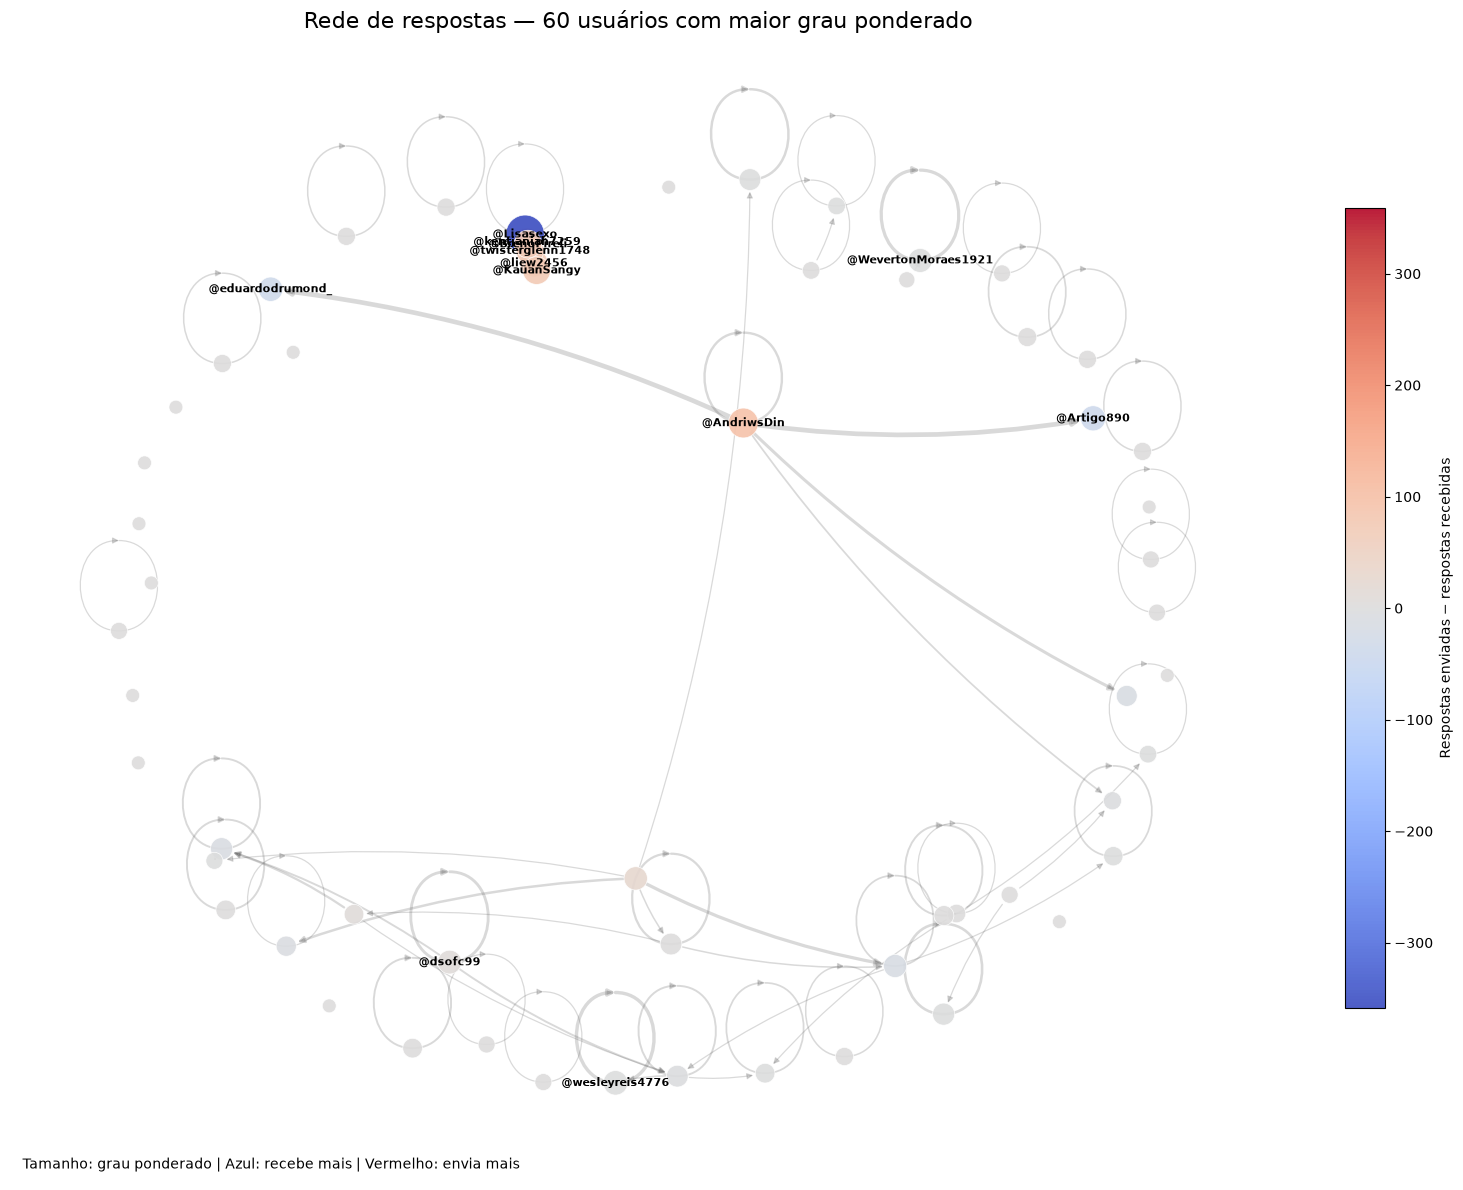

Figura salva em: outputs/figures/network_top60.png


In [15]:
import matplotlib.pyplot as plt

# Agrega arestas repetidas entre a mesma dupla apenas para esta figura.
visual_graph = nx.DiGraph()
for source, target, data in graph.edges(data=True):
    weight = int(data.get("weight", 1))
    if visual_graph.has_edge(source, target):
        visual_graph[source][target]["weight"] += weight
    else:
        visual_graph.add_edge(source, target, weight=weight)

weighted_degree = dict(visual_graph.degree(weight="weight"))
top_nodes = sorted(weighted_degree, key=weighted_degree.get, reverse=True)[:60]
view = visual_graph.subgraph(top_nodes).copy()

if view.number_of_nodes() == 0:
    raise ValueError("A rede não possui interações para visualizar.")

position = nx.spring_layout(view, seed=42, weight="weight", iterations=100)
degrees = dict(view.degree(weight="weight"))
balance = {node: view.out_degree(node, weight="weight") - view.in_degree(node, weight="weight") for node in view}
node_sizes = [100 + 35 * (degrees[node] ** 0.5) for node in view]
node_colors = [balance[node] for node in view]
edge_widths = [0.4 + min(3.0, data["weight"] ** 0.5 / 2) for _, _, data in view.edges(data=True)]
max_abs_balance = max(1, max(abs(value) for value in node_colors))

fig, ax = plt.subplots(figsize=(16, 12))
nodes_artist = nx.draw_networkx_nodes(
    view, position, node_size=node_sizes, node_color=node_colors, cmap="coolwarm",
    vmin=-max_abs_balance, vmax=max_abs_balance, alpha=0.9,
    linewidths=0.5, edgecolors="white", ax=ax,
)
nx.draw_networkx_edges(
    view, position, width=edge_widths, alpha=0.22, edge_color="#555555",
    arrows=True, arrowsize=9, connectionstyle="arc3,rad=0.08", ax=ax,
)
label_nodes = sorted(degrees, key=degrees.get, reverse=True)[:12]
labels = {node: str(graph.nodes[node].get("author_name") or node)[:24] for node in label_nodes}
nx.draw_networkx_labels(view, position, labels=labels, font_size=8, font_weight="bold", ax=ax)
colorbar = fig.colorbar(nodes_artist, ax=ax, shrink=0.7)
colorbar.set_label("Respostas enviadas − respostas recebidas")
ax.set_title("Rede de respostas — 60 usuários com maior grau ponderado", fontsize=16)
ax.text(0.01, 0.01, "Tamanho: grau ponderado | Azul: recebe mais | Vermelho: envia mais",
        transform=ax.transAxes, fontsize=10)
ax.axis("off")
fig.tight_layout()
figure_path = Path("outputs/figures/network_top60.png")
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figura salva em: {figure_path}")


## Métricas


In [16]:
import json
import math
import random
from collections import Counter
from pathlib import Path

TABLES_DIR = Path("outputs/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_SEED = 42
BETWEENNESS_SAMPLE = 500
DISTANCE_SOURCE_SAMPLE = 500

# Grafo direcionado simples: soma pesos entre a mesma dupla em todos os jogos/períodos.
metrics_graph = nx.DiGraph()
metrics_graph.add_nodes_from(graph.nodes(data=True))
for source, target, data in graph.edges(data=True):
    weight = int(data.get("weight", 1))
    if metrics_graph.has_edge(source, target):
        metrics_graph[source][target]["weight"] += weight
    else:
        metrics_graph.add_edge(source, target, weight=weight)

# Autoarestas são interações válidas para contagens, mas são retiradas das métricas estruturais.
structural_graph = metrics_graph.copy()
structural_graph.remove_edges_from(nx.selfloop_edges(structural_graph))
undirected_graph = structural_graph.to_undirected()

# Grau por nó, ponderado e não ponderado.
degree_table = pd.DataFrame({"node_id": list(structural_graph.nodes())})
degree_table["degree"] = degree_table["node_id"].map(dict(structural_graph.degree())).astype(int)
degree_table["in_degree"] = degree_table["node_id"].map(dict(structural_graph.in_degree())).astype(int)
degree_table["out_degree"] = degree_table["node_id"].map(dict(structural_graph.out_degree())).astype(int)
degree_table["weighted_degree"] = degree_table["node_id"].map(dict(structural_graph.degree(weight="weight"))).astype(int)
degree_table["weighted_in_degree"] = degree_table["node_id"].map(dict(structural_graph.in_degree(weight="weight"))).astype(int)
degree_table["weighted_out_degree"] = degree_table["node_id"].map(dict(structural_graph.out_degree(weight="weight"))).astype(int)

degree_distribution = (degree_table.groupby("degree").size().rename("node_count").reset_index())

# Componentes fracos ignoram a direção; fortes exigem caminhos nas duas direções.
weak_components = sorted(nx.weakly_connected_components(structural_graph), key=len, reverse=True)
strong_components = sorted(nx.strongly_connected_components(structural_graph), key=len, reverse=True)
component_sizes = pd.concat([
    pd.DataFrame({"component_type": "weak", "component_id": range(len(weak_components)),
                  "size": [len(component) for component in weak_components]}),
    pd.DataFrame({"component_type": "strong", "component_id": range(len(strong_components)),
                  "size": [len(component) for component in strong_components]}),
], ignore_index=True)

# Clusterização é calculada na projeção não direcionada e sem autoarestas.
clustering = nx.clustering(undirected_graph)
clustering_table = pd.DataFrame({"node_id": list(clustering), "clustering_coefficient": list(clustering.values())})

# Distâncias apenas no maior componente fracamente conectado, usando projeção não direcionada.
largest_weak_nodes = weak_components[0] if weak_components else set()
largest_component = undirected_graph.subgraph(largest_weak_nodes).copy()
all_distance_sources = list(largest_component.nodes())
distances_are_approximate = len(all_distance_sources) > DISTANCE_SOURCE_SAMPLE
rng = random.Random(RANDOM_SEED)
distance_sources = (rng.sample(all_distance_sources, DISTANCE_SOURCE_SAMPLE)
                    if distances_are_approximate else all_distance_sources)
distance_counts = Counter()
for source in distance_sources:
    for target, distance in nx.single_source_shortest_path_length(largest_component, source).items():
        if source != target:
            distance_counts[distance] += 1
distance_distribution = pd.DataFrame(sorted(distance_counts.items()), columns=["distance", "pair_count"])
distance_pair_count = sum(distance_counts.values())
average_distance = (sum(distance * count for distance, count in distance_counts.items()) / distance_pair_count
                    if distance_pair_count else math.nan)
observed_diameter = max(distance_counts, default=0)

# Centralidades. Betweenness usa amostra reproduzível quando a rede é grande.
degree_centrality = nx.degree_centrality(structural_graph)
pagerank = nx.pagerank(structural_graph, weight="weight")
betweenness_k = min(BETWEENNESS_SAMPLE, structural_graph.number_of_nodes())
betweenness_is_approximate = betweenness_k < structural_graph.number_of_nodes()
betweenness = nx.betweenness_centrality(
    structural_graph, k=betweenness_k if betweenness_is_approximate else None,
    normalized=True, weight=None, seed=RANDOM_SEED,
)
centrality_table = pd.DataFrame({
    "node_id": list(structural_graph.nodes()),
    "degree_centrality": [degree_centrality[node] for node in structural_graph],
    "pagerank": [pagerank[node] for node in structural_graph],
    "betweenness_centrality": [betweenness[node] for node in structural_graph],
}).merge(network_nodes[["node_id", "author_name"]], on="node_id", how="left")
top10 = pd.concat([
    centrality_table.nlargest(10, metric).assign(metric=metric, rank=range(1, 11))
    for metric in ["pagerank", "betweenness_centrality", "degree_centrality"]
], ignore_index=True)

# Assortatividade e pares grau do nó × grau médio de seus vizinhos para o gráfico posterior.
assortativity = nx.degree_assortativity_coefficient(undirected_graph)
average_neighbor_degree = nx.average_neighbor_degree(undirected_graph)
assortativity_data = pd.DataFrame({
    "node_id": list(undirected_graph.nodes()),
    "degree": [undirected_graph.degree(node) for node in undirected_graph],
    "average_neighbor_degree": [average_neighbor_degree[node] for node in undirected_graph],
})

network_summary = {
    "nodes": structural_graph.number_of_nodes(), "edges": structural_graph.number_of_edges(),
    "average_degree": sum(dict(structural_graph.degree()).values()) / max(1, structural_graph.number_of_nodes()),
    "weak_components": len(weak_components), "strong_components": len(strong_components),
    "largest_weak_component_size": len(largest_weak_nodes),
    "global_clustering_transitivity": nx.transitivity(undirected_graph),
    "average_clustering": nx.average_clustering(undirected_graph),
    "average_distance_largest_weak_component": average_distance,
    "observed_diameter_largest_weak_component": observed_diameter,
    "distances_approximate": distances_are_approximate,
    "distance_sources_used": len(distance_sources),
    "betweenness_approximate": betweenness_is_approximate,
    "betweenness_sample_size": betweenness_k,
    "degree_assortativity_coefficient": None if math.isnan(assortativity) else assortativity,
}

degree_table.to_csv(TABLES_DIR / "network_node_metrics.csv", index=False)
degree_distribution.to_csv(TABLES_DIR / "degree_distribution.csv", index=False)
component_sizes.to_csv(TABLES_DIR / "component_sizes.csv", index=False)
clustering_table.to_csv(TABLES_DIR / "clustering_distribution.csv", index=False)
distance_distribution.to_csv(TABLES_DIR / "distance_distribution.csv", index=False)
centrality_table.to_csv(TABLES_DIR / "centralities.csv", index=False)
top10.to_csv(TABLES_DIR / "centrality_top10.csv", index=False)
assortativity_data.to_csv(TABLES_DIR / "assortativity_data.csv", index=False)
(TABLES_DIR / "network_summary.json").write_text(json.dumps(network_summary, indent=2, ensure_ascii=False), encoding="utf-8")

display(pd.Series(network_summary, name="valor").to_frame())
display(top10[["metric", "rank", "node_id", "author_name", "pagerank",
               "betweenness_centrality", "degree_centrality"]])


,valor
nodes,40372
edges,12179
average_degree,0.603339
weak_components,30880
strong_components,40364
largest_weak_component_size,8801
global_clustering_transitivity,0.001534
average_clustering,0.000753
average_distance_largest_weak_component,5.903729
observed_diameter_largest_weak_component,17


,metric,rank,node_id,author_name,pagerank,betweenness_centrality,degree_centrality
0,pagerank,1,1cd2fbcc8864eae96f7949d1a7a6a6d569cfc9fe851c42...,@eduardomitkus1971,0.004120,3.963339e-07,0.004384
1,pagerank,2,5b6b49e2e2d434266de43ff695b1e2b8267874aabc85e0...,@pedromota9945,0.003585,0.000000e+00,0.000421
2,pagerank,3,566a470ec4f359a97f5b41aacf679e003d59a4f3ed41bc...,@Ex_Woltzel,0.003253,2.980761e-06,0.004558
3,pagerank,4,b7b189f8e43ecb9329b34600195175be2e29e6797b79cf...,@rafinhasupersayagin,0.003058,0.000000e+00,0.004607
4,pagerank,5,431a39e2c8d4ccff836515a7eee799d81395ca109fa5e2...,@O_Sobrevivente666,0.002971,5.936752e-06,0.002824
5,pagerank,6,ac55f6f03560c1dd4a098cf56aca01112f2917262cd476...,@jaumbrow,0.002133,1.981670e-07,0.003171
6,pagerank,7,f04fd3af84ae3e75ba8c1218db1c6194b7f6de082503ab...,@Orv12345,0.002119,0.000000e+00,0.002353
7,pagerank,8,6b1730715582df408478eea4650c02442e0cc341071782...,@gabrielcesar_,0.001889,0.000000e+00,0.000991
8,pagerank,9,7238c94819129cc2ecbf84f05ff599653e4b90b649da7e...,@Esequielmouradossantos,0.001858,0.000000e+00,0.002873
9,pagerank,10,37c56238758338808e4d47941f00cef1f2477da6e382a7...,@emeraldbuzznew,0.001788,4.458757e-07,0.002502


## Interpretação das métricas da rede

As tabelas seguintes organizam os indicadores por dimensão analítica. Os rankings usam pseudônimos somente para apresentação, evitando expor nomes ou hashes dos usuários.

In [17]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

# Permite executar esta célula depois de reiniciar o kernel.
if "network_summary" not in globals():
    network_summary = json.loads((Path("outputs/tables") / "network_summary.json").read_text(encoding="utf-8"))
if "top10" not in globals():
    top10 = pd.read_csv(Path("outputs/tables") / "centrality_top10.csv")

nodes_total = int(network_summary["nodes"])
largest_share = 100 * network_summary["largest_weak_component_size"] / max(1, nodes_total)
reciprocal_structure_share = 100 * (nodes_total - network_summary["strong_components"]) / max(1, nodes_total)

structure_table = pd.DataFrame([
    ["Usuários (nós)", nodes_total, "Quantidade total de usuários representados"],
    ["Relações direcionadas", int(network_summary["edges"]), "Pares únicos A → B, sem autoarestas"],
    ["Grau médio", network_summary["average_degree"], "Baixo valor indica uma rede esparsa"],
    ["Componentes fracos", int(network_summary["weak_components"]), "Grupos conectados ao ignorar a direção"],
    ["Componentes fortes", int(network_summary["strong_components"]), "Grupos com caminhos recíprocos direcionados"],
    ["Maior componente fraco", int(network_summary["largest_weak_component_size"]), f"{largest_share:.1f}% dos usuários"],
], columns=["Indicador", "Valor", "Leitura"])

cohesion_table = pd.DataFrame([
    ["Transitividade global", network_summary["global_clustering_transitivity"], "Fechamento de tríades na rede"],
    ["Clusterização média", network_summary["average_clustering"], "Coesão média das vizinhanças"],
    ["Distância média", network_summary["average_distance_largest_weak_component"], "Somente no maior componente fraco"],
    ["Diâmetro observado", network_summary["observed_diameter_largest_weak_component"], "Maior distância encontrada na amostra"],
    ["Assortatividade de grau", network_summary["degree_assortativity_coefficient"], "Negativo: usuários periféricos conectam-se a centrais"],
], columns=["Indicador", "Valor", "Leitura"])

approximation_table = pd.DataFrame([
    ["Distâncias", network_summary["distances_approximate"], network_summary["distance_sources_used"]],
    ["Betweenness", network_summary["betweenness_approximate"], network_summary["betweenness_sample_size"]],
], columns=["Métrica", "Resultado aproximado", "Tamanho da amostra"])

display(Markdown("### Estrutura e conectividade"))
display(structure_table.style.format({"Valor": lambda value: f"{value:,.3f}" if isinstance(value, float) else f"{value:,}"}))
display(Markdown("### Coesão, distâncias e mistura"))
display(cohesion_table.style.format({"Valor": "{:.6f}"}))
display(Markdown("### Aproximações computacionais"))
display(approximation_table)

# Pseudônimos são locais a esta apresentação e não permitem identificar os autores.
private_ids = sorted(top10["node_id"].astype(str).unique())
pseudonyms = {node_id: f"Usuário {index:03d}" for index, node_id in enumerate(private_ids, start=1)}
ranking_table = top10.copy()
ranking_table["Usuário"] = ranking_table["node_id"].astype(str).map(pseudonyms)
ranking_table["Métrica"] = ranking_table["metric"].map({
    "pagerank": "PageRank",
    "betweenness_centrality": "Intermediação",
    "degree_centrality": "Centralidade de grau",
})
ranking_table["Valor"] = ranking_table.apply(lambda row: row[row["metric"]], axis=1)
ranking_table = ranking_table[["Métrica", "rank", "Usuário", "Valor"]].rename(columns={"rank": "Posição"})
display(Markdown("### Dez usuários mais centrais por métrica"))
display(ranking_table.style.format({"Valor": "{:.8f}"}).hide(axis="index"))

display(Markdown(f"""
### Síntese interpretativa

- A rede é **muito esparsa**: o grau médio é `{network_summary['average_degree']:.3f}`, portanto a maioria dos usuários estabelece poucas relações de resposta.
- Há **forte fragmentação**, com `{network_summary['weak_components']:,}` componentes fracos. Ainda assim, o maior componente reúne `{network_summary['largest_weak_component_size']:,}` usuários (`{largest_share:.1f}%` da rede).
- A proximidade entre o número de componentes fortes e o número de nós revela **pouca reciprocidade e poucos ciclos** nas conversações.
- A clusterização média de `{network_summary['average_clustering']:.6f}` mostra que usuários ligados à mesma pessoa raramente interagem entre si.
- A assortatividade de `{network_summary['degree_assortativity_coefficient']:.3f}` indica uma estrutura **dissortativa**, em que usuários periféricos tendem a interagir com usuários mais centrais.
- PageRank e centralidade de grau identificam visibilidade e volume de conexões; a intermediação destaca usuários que funcionam como pontes entre regiões da rede.

### Cuidados metodológicos

As distâncias, o diâmetro observado e a betweenness foram estimados com amostras reproduzíveis. Pequenas diferenças nos rankings não devem ser tratadas como posições exatas. Além disso, estes valores descrevem a rede agregada; a questão de pesquisa exige comparações posteriores por partida, período e resultado.
"""))


### Estrutura e conectividade

,Indicador,Valor,Leitura
0,Usuários (nós),"40,372.000",Quantidade total de usuários representados
1,Relações direcionadas,"12,179.000","Pares únicos A → B, sem autoarestas"
2,Grau médio,0.603,Baixo valor indica uma rede esparsa
3,Componentes fracos,"30,880.000",Grupos conectados ao ignorar a direção
4,Componentes fortes,"40,364.000",Grupos com caminhos recíprocos direcionados
5,Maior componente fraco,"8,801.000",21.8% dos usuários


### Coesão, distâncias e mistura

,Indicador,Valor,Leitura
0,Transitividade global,0.001534,Fechamento de tríades na rede
1,Clusterização média,0.000753,Coesão média das vizinhanças
2,Distância média,5.903729,Somente no maior componente fraco
3,Diâmetro observado,17.000000,Maior distância encontrada na amostra
4,Assortatividade de grau,-0.229261,Negativo: usuários periféricos conectam-se a centrais


### Aproximações computacionais

,Métrica,Resultado aproximado,Tamanho da amostra
0,Distâncias,True,500
1,Betweenness,True,500


### Dez usuários mais centrais por métrica

Métrica,Posição,Usuário,Valor
PageRank,1,Usuário 003,0.00411957
PageRank,2,Usuário 012,0.00358461
PageRank,3,Usuário 011,0.00325335
PageRank,4,Usuário 019,0.00305786
PageRank,5,Usuário 009,0.00297088
PageRank,6,Usuário 018,0.00213259
PageRank,7,Usuário 022,0.00211913
PageRank,8,Usuário 013,0.00188858
PageRank,9,Usuário 014,0.00185772
PageRank,10,Usuário 008,0.00178803



### Síntese interpretativa

- A rede é **muito esparsa**: o grau médio é `0.603`, portanto a maioria dos usuários estabelece poucas relações de resposta.
- Há **forte fragmentação**, com `30,880` componentes fracos. Ainda assim, o maior componente reúne `8,801` usuários (`21.8%` da rede).
- A proximidade entre o número de componentes fortes e o número de nós revela **pouca reciprocidade e poucos ciclos** nas conversações.
- A clusterização média de `0.000753` mostra que usuários ligados à mesma pessoa raramente interagem entre si.
- A assortatividade de `-0.229` indica uma estrutura **dissortativa**, em que usuários periféricos tendem a interagir com usuários mais centrais.
- PageRank e centralidade de grau identificam visibilidade e volume de conexões; a intermediação destaca usuários que funcionam como pontes entre regiões da rede.

### Cuidados metodológicos

As distâncias, o diâmetro observado e a betweenness foram estimados com amostras reproduzíveis. Pequenas diferenças nos rankings não devem ser tratadas como posições exatas. Além disso, estes valores descrevem a rede agregada; a questão de pesquisa exige comparações posteriores por partida, período e resultado.


## Sentimento, Temas e entidades

In [18]:
import importlib.metadata
import json
import re
from pathlib import Path

import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import pipeline

NLP_OUTPUT = Path("data/processed/comments_nlp.csv")
SENTIMENT_CHECKPOINT = Path("data/processed/sentiment_checkpoint.csv")
NLP_METADATA = Path("outputs/tables/nlp_metadata.json")
ENTITY_PATH = Path("data/reference/entities.csv")
SENTIMENT_MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
SENTIMENT_REVISION = "main"  # o commit resolvido é registrado nos metadados
SENTIMENT_BATCH_SIZE = 32 if torch.cuda.is_available() else 8
CHECKPOINT_EVERY = 500

if "comments_clean" not in globals():
    comments_clean = pd.read_csv(Path("data/processed/comments_clean.csv"), dtype={"comment_id": "string"})

def preprocess_social_text(value: object) -> str:
    """Preserva conteúdo, substituindo usuários e links conforme o modelo recomenda."""
    if pd.isna(value) or not str(value).strip():
        return ""
    tokens = []
    for token in str(value).split():
        if token.startswith("@") and len(token) > 1:
            tokens.append("@user")
        elif token.lower().startswith(("http://", "https://", "www.")):
            tokens.append("http")
        else:
            tokens.append(token)
    return " ".join(tokens)

# O checkpoint permite interromper e executar novamente sem perder inferências prontas.
checkpoint_columns = ["comment_id", "sentiment", "sentiment_score"]
if SENTIMENT_CHECKPOINT.exists():
    sentiment_done = pd.read_csv(SENTIMENT_CHECKPOINT, dtype={"comment_id": "string"}).drop_duplicates("comment_id", keep="last")
else:
    sentiment_done = pd.DataFrame(columns=checkpoint_columns).astype({"comment_id": "string"})
done_ids = set(sentiment_done["comment_id"].dropna())
pending = comments_clean.loc[~comments_clean["comment_id"].isin(done_ids), ["comment_id", "text_original"]].copy()

device = 0 if torch.cuda.is_available() else -1
sentiment_classifier = pipeline(
    "sentiment-analysis", model=SENTIMENT_MODEL, tokenizer=SENTIMENT_MODEL,
    revision=SENTIMENT_REVISION, device=device,
)
label_map = {"label_0": "negative", "label_1": "neutral", "label_2": "positive",
             "negative": "negative", "neutral": "neutral", "positive": "positive"}

for start in tqdm(range(0, len(pending), CHECKPOINT_EVERY), desc="Sentimento"):
    chunk = pending.iloc[start:start + CHECKPOINT_EVERY]
    texts = [preprocess_social_text(value) for value in chunk["text_original"]]
    nonempty_positions = [index for index, text in enumerate(texts) if text]
    predictions = [None] * len(texts)
    if nonempty_positions:
        model_inputs = [texts[index] for index in nonempty_positions]
        model_outputs = sentiment_classifier(
            model_inputs, batch_size=SENTIMENT_BATCH_SIZE, truncation=True, max_length=512,
        )
        for index, output in zip(nonempty_positions, model_outputs):
            predictions[index] = output
    rows = []
    for comment_id, prediction in zip(chunk["comment_id"], predictions):
        if prediction is None:
            rows.append({"comment_id": comment_id, "sentiment": "neutral", "sentiment_score": 1.0})
        else:
            label = label_map.get(str(prediction["label"]).casefold(), str(prediction["label"]).casefold())
            rows.append({"comment_id": comment_id, "sentiment": label, "sentiment_score": float(prediction["score"])})
    pd.DataFrame(rows).to_csv(
        SENTIMENT_CHECKPOINT, mode="a", header=not SENTIMENT_CHECKPOINT.exists(), index=False,
    )

sentiment_results = pd.read_csv(SENTIMENT_CHECKPOINT, dtype={"comment_id": "string"}).drop_duplicates("comment_id", keep="last")
comments_nlp = comments_clean.drop(columns=["sentiment", "sentiment_score"], errors="ignore").merge(
    sentiment_results, on="comment_id", how="left", validate="one_to_one",
)

# Temas multilabel baseados em regras transparentes e auditáveis.
TOPIC_PATTERNS = {
    "arbitragem": r"\b(?:árbitro|arbitro|juiz|juíza|var|apito|pênalti|penalti|expulsão|cartão)\b",
    "treinador": r"\b(?:treinador|técnico|tecnico|professor|comissão técnica)\b",
    "jogador": r"\b(?:jogador|atacante|goleiro|zagueiro|lateral|meia|volante|camisa 10)\b",
    "diretoria": r"\b(?:diretoria|presidente|gestão|gestao|dirigente|dono|saf)\b",
    "torcida": r"\b(?:torcida|torcedor|massa|china azul|arquibancada|organizada)\b",
    "rivalidade": r"\b(?:rival|rivalidade|clássico|classico|galo|raposa|cruzeiro|atlético|atletico)\b",
    "desempenho": r"\b(?:jogou|jogando|desempenho|partida|marcação|marcacao|ataque|defesa|time|equipe)\b",
    "escalação": r"\b(?:escalação|escalacao|escalado|titular|reserva|substituição|substituicao)\b",
    "contratação": r"\b(?:contratação|contratacao|contratar|reforço|reforco|mercado|vender|emprestar)\b",
    "resultado da partida": r"\b(?:resultado|placar|vitória|vitoria|derrota|empate|ganhou|perdeu|classificado|eliminado|gol)\b",
}
compiled_topics = {topic: re.compile(pattern, flags=re.IGNORECASE) for topic, pattern in TOPIC_PATTERNS.items()}

def detect_topics(text: object) -> list[str]:
    value = "" if pd.isna(text) else str(text)
    labels = [topic for topic, pattern in compiled_topics.items() if pattern.search(value)]
    return labels or ["outros"]

comments_nlp["topics"] = comments_nlp["text_clean"].map(detect_topics)
for topic in [*TOPIC_PATTERNS, "outros"]:
    comments_nlp[f"topic_{topic.replace(' ', '_')}"] = comments_nlp["topics"].map(lambda labels, selected=topic: selected in labels)

# Entidades são reconhecidas por aliases cadastrados, mantendo nome canônico e tipo.
entities_reference = pd.read_csv(ENTITY_PATH, dtype="string").dropna(subset=["canonical_name", "entity_type", "alias"])
entity_patterns = [
    (row.canonical_name, row.entity_type, re.compile(rf"(?<!\w){re.escape(str(row.alias))}(?!\w)", re.IGNORECASE))
    for row in entities_reference.itertuples(index=False) if str(row.alias).strip()
]

def detect_entities(text: object) -> tuple[list[str], list[str]]:
    value = "" if pd.isna(text) else str(text)
    found = {(canonical, entity_type) for canonical, entity_type, pattern in entity_patterns if pattern.search(value)}
    return sorted({item[0] for item in found}), sorted({item[1] for item in found})

entity_hits = comments_nlp["text_original"].map(detect_entities)
comments_nlp["entities_mentioned"] = entity_hits.map(lambda item: item[0])
comments_nlp["entity_types_mentioned"] = entity_hits.map(lambda item: item[1])
comments_nlp.to_csv(NLP_OUTPUT, index=False)

resolved_revision = getattr(sentiment_classifier.model.config, "_commit_hash", None)
nlp_metadata = {
    "sentiment_model": SENTIMENT_MODEL, "requested_revision": SENTIMENT_REVISION,
    "resolved_revision": resolved_revision, "transformers_version": importlib.metadata.version("transformers"),
    "device": "cuda" if torch.cuda.is_available() else "cpu", "batch_size": SENTIMENT_BATCH_SIZE,
    "labels": ["negative", "neutral", "positive"],
    "topics_method": "multilabel_keyword_rules_v1", "entities_method": "alias_dictionary_v1",
    "limitations": ["ironia e sarcasmo", "domínio YouTube diferente do Twitter",
                    "temas dependem do vocabulário das regras", "entidades dependem dos aliases cadastrados"],
}
NLP_METADATA.parent.mkdir(parents=True, exist_ok=True)
NLP_METADATA.write_text(json.dumps(nlp_metadata, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Comentários analisados: {len(comments_nlp):,}")
print(f"Modelo: {SENTIMENT_MODEL} | commit: {resolved_revision}")
print(f"Aliases de entidades carregados: {len(entity_patterns):,}")
display(comments_nlp["sentiment"].value_counts(dropna=False).rename("comentários").to_frame())
display(pd.Series({topic: comments_nlp[f"topic_{topic.replace(' ', '_')}"].sum()
                   for topic in [*TOPIC_PATTERNS, "outros"]}, name="comentários").sort_values(ascending=False).to_frame())
display(comments_nlp[["text_original", "sentiment", "sentiment_score", "topics", "entities_mentioned"]].head())


Device set to use cpu
Sentimento: 0it [00:00, ?it/s]


Comentários analisados: 58,910
Modelo: cardiffnlp/twitter-xlm-roberta-base-sentiment | commit: f2f1202b1bdeb07342385c3f807f9c07cd8f5cf8
Aliases de entidades carregados: 0


,comentários
sentiment,
negative,29139
neutral,17463
positive,12308


,comentários
outros,40985
rivalidade,9991
desempenho,3201
jogador,3187
resultado da partida,3072
arbitragem,2640
torcida,1441
treinador,250
escalação,173
diretoria,169


,text_original,sentiment,sentiment_score,topics,entities_mentioned
0,Chupa galo aqui e Vila Belmiro peixaõ estou co...,neutral,0.500852,[rivalidade],[]
1,Crizeiro classificado Zica santista fanatico t...,negative,0.491718,"[rivalidade, resultado da partida]",[]
2,Passa o cruzeiro galo eliminado chupa galo,neutral,0.445397,"[rivalidade, resultado da partida]",[]
3,Sou santista mais sou crizeiro melgor que galo,neutral,0.474908,[rivalidade],[]
4,Cruzeiro tá ganhando,positive,0.732674,[rivalidade],[]


## Análise por resultado da partida

A análise abaixo compara sentimento e temas conforme o vencedor de cada clássico. O pós-jogo é o recorte principal, pois somente nele o resultado já era conhecido.

### Resultados e sentimento pós-jogo por clássico

data,fixture,score,outcome,comentários pré,comentários pós,negative pós (%),neutral pós (%),positive pós (%)
01/09/2026,Atlético-MG × Cruzeiro,2–1,Atlético-MG venceu,25,3761,48.0,28.9,23.1
25/08/2026,Cruzeiro × Atlético-MG,1–1,Empate,81,2100,64.7,23.5,11.9
02/05/2026,Cruzeiro × Atlético-MG,1–3,Atlético-MG venceu,66,2936,58.4,28.2,13.4
08/03/2026,Cruzeiro × Atlético-MG,1–0,Cruzeiro venceu,26,20204,49.0,27.3,23.8
25/01/2026,Atlético-MG × Cruzeiro,2–1,Atlético-MG venceu,52,3185,43.4,35.3,21.3
15/10/2025,Atlético-MG × Cruzeiro,1–1,Empate,23,3849,69.3,23.6,7.1
11/09/2025,Cruzeiro × Atlético-MG,2–0,Cruzeiro venceu,6,4558,33.3,34.1,32.6
27/08/2025,Atlético-MG × Cruzeiro,0–2,Cruzeiro venceu,120,3788,48.8,32.2,18.9
18/05/2025,Cruzeiro × Atlético-MG,0–0,Empate,53,1316,57.8,29.6,12.7
09/02/2025,Cruzeiro × Atlético-MG,0–2,Atlético-MG venceu,2,4972,48.2,29.4,22.4


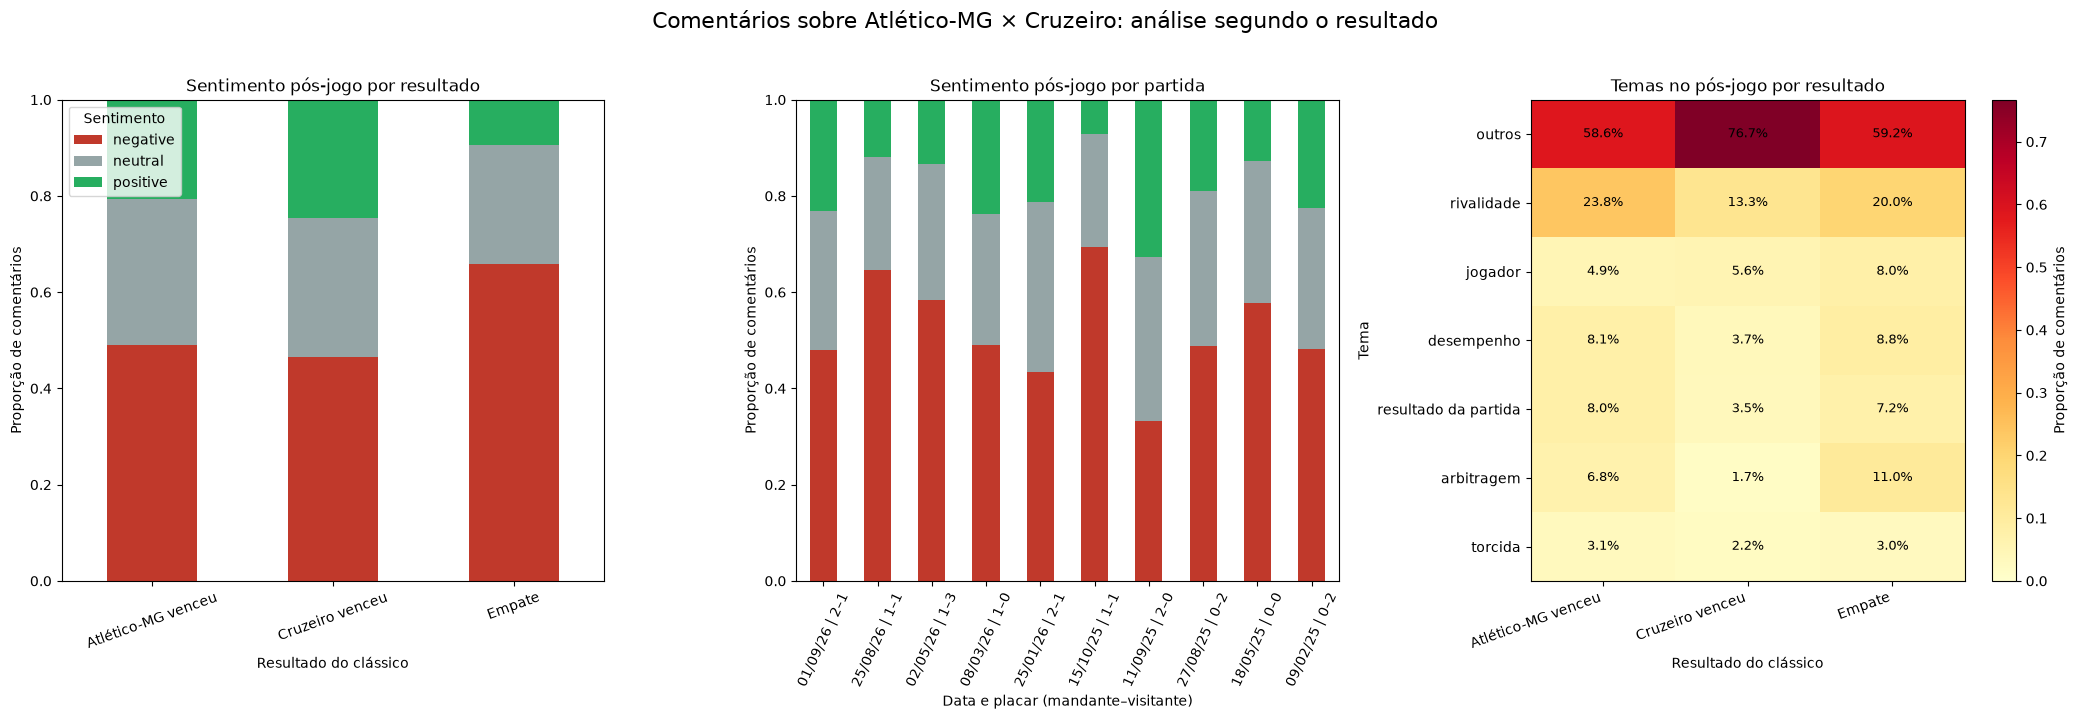

### Análise descritiva

- Após **atlético-mg venceu**, 49.1% dos comentários foram negativos e 20.6% positivos; em relação ao pré-jogo houve aumento de 18.8 ponto(s) percentual(is) na negatividade.
- Após **cruzeiro venceu**, 46.5% dos comentários foram negativos e 24.5% positivos; em relação ao pré-jogo houve aumento de 10.9 ponto(s) percentual(is) na negatividade.
- Após **empate**, 65.9% dos comentários foram negativos e 9.5% positivos; em relação ao pré-jogo houve aumento de 38.5 ponto(s) percentual(is) na negatividade.

No conjunto completo, **49.5%** dos comentários foram classificados como negativos. O clássico com maior proporção negativa no pós-jogo foi **Atlético-MG × Cruzeiro (1–1, 15/10/2025)**, com **69.3%**. A maior proporção positiva ocorreu em **Cruzeiro × Atlético-MG (2–0, 11/09/2025)**, com **32.6%**.

Os resultados descrevem associação, não causalidade. Não sabemos para qual clube cada usuário torce; portanto, uma vitória do Atlético-MG não equivale necessariamente a uma vitória para todos os comentaristas. Além disso, `36.3%` das previsões tiveram confiança inferior a 0,60, e ironia, sarcasmo, provocações e erros ortográficos podem reduzir a precisão do modelo. A hipótese deve ser avaliada também por temas, partida e validação manual de uma amostra estratificada.


Figura salva em: outputs/figures/analysis_by_match_result.png


In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

if "comments_nlp" not in globals():
    comments_nlp = pd.read_csv("data/processed/comments_nlp.csv", dtype={"comment_id": "string", "match_id": "string"})
matches_analysis = pd.read_csv("data/raw/matches.csv", dtype={"match_id": "string"})
matches_analysis["match_date"] = pd.to_datetime(matches_analysis["match_date"], errors="coerce")

match_columns = ["match_id", "match_date", "home_team", "away_team", "home_score",
                 "away_score", "winner", "result_atletico", "result_cruzeiro"]
analysis_df = comments_nlp.merge(matches_analysis[match_columns], on="match_id", how="left", validate="many_to_one")
analysis_window_mask = analysis_df["within_comment_window"].astype("string").str.lower().eq("true")
analysis_df = analysis_df.loc[analysis_window_mask & analysis_df["comment_period"].isin(["pre_game", "post_game"])].copy()
analysis_df["period"] = analysis_df["comment_period"]
analysis_df["outcome"] = analysis_df["winner"].map({
    "Atlético-MG": "Atlético-MG venceu", "Cruzeiro": "Cruzeiro venceu", "draw": "Empate",
}).fillna("Resultado desconhecido")
analysis_df["fixture"] = analysis_df["home_team"] + " × " + analysis_df["away_team"]
analysis_df["score"] = analysis_df["home_score"].astype("Int64").astype(str) + "–" + analysis_df["away_score"].astype("Int64").astype(str)

sentiment_order = ["negative", "neutral", "positive"]
outcome_order = [item for item in ["Atlético-MG venceu", "Cruzeiro venceu", "Empate"] if item in set(analysis_df["outcome"])]
colors = {"negative": "#c0392b", "neutral": "#95a5a6", "positive": "#27ae60"}

# Tabela por partida: volume e proporções de sentimento no pós-jogo.
match_base = (matches_analysis.sort_values("match_date", ascending=False)
              .assign(fixture=lambda frame: frame["home_team"] + " × " + frame["away_team"],
                      score=lambda frame: frame["home_score"].astype("Int64").astype(str) + "–" + frame["away_score"].astype("Int64").astype(str),
                      outcome=lambda frame: frame["winner"].map({"Atlético-MG": "Atlético-MG venceu", "Cruzeiro": "Cruzeiro venceu", "draw": "Empate"})))
volume = analysis_df.groupby(["match_id", "period"]).size().unstack(fill_value=0)
post_by_match = (analysis_df.loc[analysis_df["period"].eq("post_game")]
                 .groupby(["match_id", "sentiment"]).size().unstack(fill_value=0)
                 .reindex(columns=sentiment_order, fill_value=0))
post_by_match_pct = post_by_match.div(post_by_match.sum(axis=1).replace(0, pd.NA), axis=0).fillna(0)
match_summary = match_base[["match_id", "match_date", "fixture", "score", "outcome"]].set_index("match_id")
match_summary["comentários pré"] = volume.get("pre_game", pd.Series(dtype=int))
match_summary["comentários pós"] = volume.get("post_game", pd.Series(dtype=int))
for sentiment in sentiment_order:
    match_summary[f"{sentiment} pós (%)"] = 100 * post_by_match_pct[sentiment]
match_summary = match_summary.fillna(0).reset_index(drop=True)
match_summary["data"] = match_summary.pop("match_date").dt.strftime("%d/%m/%Y")
match_summary = match_summary[["data", "fixture", "score", "outcome", "comentários pré",
                               "comentários pós", "negative pós (%)", "neutral pós (%)", "positive pós (%)"]]
display(Markdown("### Resultados e sentimento pós-jogo por clássico"))
display(match_summary.style.format({"negative pós (%)": "{:.1f}", "neutral pós (%)": "{:.1f}", "positive pós (%)": "{:.1f}"}).hide(axis="index"))
match_summary.to_csv("outputs/tables/sentiment_by_match.csv", index=False)

# Distribuição por vencedor e período.
sentiment_counts = (analysis_df.groupby(["outcome", "period", "sentiment"]).size()
                    .rename("comments").reset_index())
sentiment_counts["proportion"] = sentiment_counts["comments"] / sentiment_counts.groupby(["outcome", "period"])["comments"].transform("sum")
sentiment_counts.to_csv("outputs/tables/sentiment_by_winner_period.csv", index=False)
post_outcome = (sentiment_counts.loc[sentiment_counts["period"].eq("post_game")]
                .pivot(index="outcome", columns="sentiment", values="proportion")
                .reindex(index=outcome_order, columns=sentiment_order).fillna(0))

# Taxas dos temas no pós-jogo; um comentário pode aparecer em vários temas.
topic_columns = [column for column in analysis_df.columns if column.startswith("topic_")]
for column in topic_columns:
    if analysis_df[column].dtype != bool:
        analysis_df[column] = analysis_df[column].astype("string").str.lower().eq("true")
post_df = analysis_df.loc[analysis_df["period"].eq("post_game")].copy()
topic_rates = post_df.groupby("outcome")[topic_columns].mean().reindex(outcome_order).fillna(0)
top_topic_columns = post_df[topic_columns].mean().nlargest(min(7, len(topic_columns))).index.tolist()
topic_plot = topic_rates[top_topic_columns].rename(columns=lambda value: value.removeprefix("topic_").replace("_", " "))
topic_rates.reset_index().to_csv("outputs/tables/topics_by_winner_postgame.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
post_outcome.plot(kind="bar", stacked=True, color=[colors[item] for item in sentiment_order], ax=axes[0])
axes[0].set_title("Sentimento pós-jogo por resultado")
axes[0].set_xlabel("Resultado do clássico")
axes[0].set_ylabel("Proporção de comentários")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Sentimento")
axes[0].tick_params(axis="x", rotation=20)

match_chart = post_by_match_pct.reindex(match_base["match_id"]).copy()
match_chart.index = [f"{date:%d/%m/%y} | {score}" for date, score in zip(match_base["match_date"], match_base["score"])]
match_chart.plot(kind="bar", stacked=True, color=[colors[item] for item in sentiment_order], ax=axes[1])
axes[1].set_title("Sentimento pós-jogo por partida")
axes[1].set_xlabel("Data e placar (mandante–visitante)")
axes[1].set_ylabel("Proporção de comentários")
axes[1].set_ylim(0, 1)
axes[1].get_legend().remove()  # a legenda já aparece no primeiro painel
axes[1].tick_params(axis="x", rotation=65)

image = axes[2].imshow(topic_plot.T.values, aspect="auto", cmap="YlOrRd", vmin=0)
axes[2].set_title("Temas no pós-jogo por resultado")
axes[2].set_xlabel("Resultado do clássico")
axes[2].set_ylabel("Tema")
axes[2].set_xticks(range(len(topic_plot.index)), topic_plot.index, rotation=20, ha="right")
axes[2].set_yticks(range(len(topic_plot.columns)), topic_plot.columns)
for row in range(len(topic_plot.columns)):
    for column in range(len(topic_plot.index)):
        axes[2].text(column, row, f"{100 * topic_plot.iloc[column, row]:.1f}%", ha="center", va="center", fontsize=9)
fig.colorbar(image, ax=axes[2], label="Proporção de comentários")
fig.suptitle("Comentários sobre Atlético-MG × Cruzeiro: análise segundo o resultado", fontsize=16, y=1.02)
fig.tight_layout()
result_figure = Path("outputs/figures/analysis_by_match_result.png")
fig.savefig(result_figure, dpi=300, bbox_inches="tight")
plt.show()

# Síntese textual gerada a partir dos valores observados.
def sentiment_rate(outcome: str, period: str, sentiment: str) -> float:
    selected = sentiment_counts.loc[(sentiment_counts["outcome"] == outcome) &
                                    (sentiment_counts["period"] == period) &
                                    (sentiment_counts["sentiment"] == sentiment), "proportion"]
    return float(selected.iloc[0]) if len(selected) else float("nan")

outcome_sentences = []
for outcome in outcome_order:
    negative_post = sentiment_rate(outcome, "post_game", "negative")
    positive_post = sentiment_rate(outcome, "post_game", "positive")
    negative_pre = sentiment_rate(outcome, "pre_game", "negative")
    delta = 100 * (negative_post - negative_pre)
    direction = "aumento" if delta >= 0 else "redução"
    outcome_sentences.append(f"- Após **{outcome.lower()}**, {100*negative_post:.1f}% dos comentários foram negativos e {100*positive_post:.1f}% positivos; em relação ao pré-jogo houve {direction} de {abs(delta):.1f} ponto(s) percentual(is) na negatividade.")

most_negative = match_summary.loc[match_summary["negative pós (%)"].idxmax()]
most_positive = match_summary.loc[match_summary["positive pós (%)"].idxmax()]
low_confidence = 100 * comments_nlp["sentiment_score"].lt(0.60).mean()
overall_negative = 100 * comments_nlp["sentiment"].eq("negative").mean()

display(Markdown("### Análise descritiva\n\n" + "\n".join(outcome_sentences) + f"""

No conjunto completo, **{overall_negative:.1f}%** dos comentários foram classificados como negativos. O clássico com maior proporção negativa no pós-jogo foi **{most_negative['fixture']} ({most_negative['score']}, {most_negative['data']})**, com **{most_negative['negative pós (%)']:.1f}%**. A maior proporção positiva ocorreu em **{most_positive['fixture']} ({most_positive['score']}, {most_positive['data']})**, com **{most_positive['positive pós (%)']:.1f}%**.

Os resultados descrevem associação, não causalidade. Não sabemos para qual clube cada usuário torce; portanto, uma vitória do Atlético-MG não equivale necessariamente a uma vitória para todos os comentaristas. Além disso, `{low_confidence:.1f}%` das previsões tiveram confiança inferior a 0,60, e ironia, sarcasmo, provocações e erros ortográficos podem reduzir a precisão do modelo. A hipótese deve ser avaliada também por temas, partida e validação manual de uma amostra estratificada.
"""))
print(f"Figura salva em: {result_figure}")


# Fase 9 — Comparações e visualizações

Esta fase compara pré e pós-jogo, resultado do clássico e partida individual. As tabelas são exportadas para `outputs/tables/` e as figuras para `outputs/figures/`.

In [20]:
import ast
import re
from collections import Counter
from pathlib import Path

import pandas as pd

TABLES_DIR = Path("outputs/tables")
FIGURES_DIR = Path("outputs/figures")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if "comments_nlp" not in globals():
    comments_nlp = pd.read_csv("data/processed/comments_nlp.csv", dtype={"comment_id": "string", "match_id": "string"})
matches_phase9 = pd.read_csv("data/raw/matches.csv", dtype={"match_id": "string"})
matches_phase9["match_date"] = pd.to_datetime(matches_phase9["match_date"], errors="coerce")
match_info = matches_phase9[["match_id", "match_date", "home_team", "away_team", "home_score", "away_score", "winner"]].copy()
phase9 = comments_nlp.merge(match_info, on="match_id", how="left", validate="many_to_one")
phase9_window_mask = phase9["within_comment_window"].astype("string").str.lower().eq("true")
phase9 = phase9.loc[phase9_window_mask & phase9["comment_period"].isin(["pre_game", "post_game"])].copy()
phase9["outcome"] = phase9["winner"].map({"Atlético-MG": "Atlético-MG venceu", "Cruzeiro": "Cruzeiro venceu", "draw": "Empate"})
phase9["period_label"] = phase9["comment_period"].map({"pre_game": "Pré-jogo", "post_game": "Pós-jogo"})
phase9["like_count"] = pd.to_numeric(phase9["like_count"], errors="coerce").fillna(0)
phase9["sentiment_score"] = pd.to_numeric(phase9["sentiment_score"], errors="coerce")

comparison = (phase9.groupby(["outcome", "period_label"], observed=True)
              .agg(comments=("comment_id", "size"), unique_users=("author_channel_id", "nunique"),
                   likes_total=("like_count", "sum"), likes_mean=("like_count", "mean"),
                   likes_median=("like_count", "median"), mean_model_confidence=("sentiment_score", "mean"))
              .reset_index())
sentiment_long = (phase9.groupby(["outcome", "period_label", "sentiment"], observed=True)
                  .size().rename("sentiment_comments").reset_index())
sentiment_long["proportion"] = (sentiment_long["sentiment_comments"] /
                                  sentiment_long.groupby(["outcome", "period_label"])["sentiment_comments"].transform("sum"))
sentiment_wide = sentiment_long.pivot(index=["outcome", "period_label"], columns="sentiment", values="proportion").reset_index()
comparison = comparison.merge(sentiment_wide, on=["outcome", "period_label"], how="left")
comparison.to_csv(TABLES_DIR / "comparison_outcome_period.csv", index=False)

topic_columns = [column for column in phase9.columns if column.startswith("topic_")]
for column in topic_columns:
    phase9[column] = phase9[column].astype("string").str.lower().map({"true": True, "false": False}).fillna(False)
topic_comparison = (phase9.groupby(["outcome", "period_label"], observed=True)[topic_columns].mean()
                    .rename(columns=lambda value: value.removeprefix("topic_").replace("_", " ")))
topic_comparison.to_csv(TABLES_DIR / "comparison_topics.csv")

PORTUGUESE_STOPWORDS = {
    "a", "à", "agora", "ainda", "ao", "aos", "as", "até", "com", "como", "da", "das",
    "de", "dela", "dele", "do", "dos", "e", "é", "ela", "ele", "eles", "em", "essa",
    "esse", "esta", "este", "eu", "foi", "já", "mais", "mas", "me", "mesmo", "meu",
    "muito", "na", "não", "nas", "no", "nos", "o", "os", "ou", "para", "pela", "pelo",
    "por", "porque", "pra", "que", "quem", "se", "sem", "ser", "só", "sua", "também",
    "tem", "um", "uma", "vai", "você", "vocês"
}
def frequent_words(frame: pd.DataFrame, n: int = 15) -> pd.DataFrame:
    tokens = Counter(token for text in frame["text_clean"].fillna("")
                     for token in re.findall(r"[a-záàâãéêíóôõúç]+", str(text).casefold())
                     if len(token) > 2 and token not in PORTUGUESE_STOPWORDS)
    return pd.DataFrame(tokens.most_common(n), columns=["word", "frequency"])

word_tables = []
for (outcome, period), group in phase9.groupby(["outcome", "period_label"], observed=True):
    words = frequent_words(group).assign(outcome=outcome, period=period)
    word_tables.append(words)
word_comparison = pd.concat(word_tables, ignore_index=True)
word_comparison.to_csv(TABLES_DIR / "frequent_words_by_outcome_period.csv", index=False)

def as_list(value: object) -> list[str]:
    if isinstance(value, list): return value
    if pd.isna(value) or not str(value).strip(): return []
    try: return list(ast.literal_eval(str(value)))
    except (ValueError, SyntaxError): return []
entity_counter = Counter(entity for value in phase9["entities_mentioned"] for entity in as_list(value))
entity_frequency = pd.DataFrame(entity_counter.most_common(), columns=["entity", "mentions"])
entity_frequency.to_csv(TABLES_DIR / "entity_frequency.csv", index=False)

display(comparison.style.format({"likes_mean": "{:.2f}", "likes_median": "{:.1f}",
                                 "mean_model_confidence": "{:.3f}", "negative": "{:.1%}",
                                 "neutral": "{:.1%}", "positive": "{:.1%}"}).hide(axis="index"))


outcome,period_label,comments,unique_users,likes_total,likes_mean,likes_median,mean_model_confidence,negative,neutral,positive
Atlético-MG venceu,Pré-jogo,145,110,136,0.94,0.0,0.668,30.3%,46.2%,23.4%
Atlético-MG venceu,Pós-jogo,14854,10586,125805,8.47,0.0,0.683,49.1%,30.3%,20.6%
Cruzeiro venceu,Pré-jogo,152,127,454,2.99,0.0,0.625,35.5%,47.4%,17.1%
Cruzeiro venceu,Pós-jogo,28550,21864,263685,9.24,0.0,0.698,46.5%,29.0%,24.5%
Empate,Pré-jogo,157,128,352,2.24,1.0,0.671,27.4%,47.8%,24.8%
Empate,Pós-jogo,7265,4796,46285,6.37,0.0,0.730,65.9%,24.7%,9.5%


In [21]:
import math
import networkx as nx

NETWORK_BETWEENNESS_SAMPLE = 100
def network_metrics_for(frame: pd.DataFrame) -> dict[str, float | int | None]:
    directed = nx.DiGraph()
    users = frame["author_channel_id"].dropna().astype(str)
    directed.add_nodes_from(users)
    reply_mask = frame["is_reply"].astype("string").str.lower().eq("true")
    edges = frame.loc[reply_mask & frame["author_channel_id"].notna() & frame["parent_author_channel_id"].notna(),
                      ["author_channel_id", "parent_author_channel_id"]]
    for (source, target), weight in edges.groupby(["author_channel_id", "parent_author_channel_id"]).size().items():
        directed.add_edge(str(source), str(target), weight=int(weight))
    directed.remove_edges_from(nx.selfloop_edges(directed))
    undirected = directed.to_undirected()
    node_count, edge_count = directed.number_of_nodes(), directed.number_of_edges()
    if node_count == 0:
        return {key: 0 for key in ["nodes", "edges", "average_degree", "average_clustering",
                                         "assortativity", "max_pagerank", "max_degree_centrality", "max_betweenness"]}
    degree_centrality = nx.degree_centrality(directed) if node_count > 1 else {node: 0 for node in directed}
    pagerank = nx.pagerank(directed, weight="weight")
    sample = min(NETWORK_BETWEENNESS_SAMPLE, node_count)
    betweenness = nx.betweenness_centrality(directed, k=sample if sample < node_count else None, seed=42)
    assortativity = nx.degree_assortativity_coefficient(undirected) if edge_count else math.nan
    return {"nodes": node_count, "edges": edge_count,
            "average_degree": sum(dict(directed.degree()).values()) / node_count,
            "average_clustering": nx.average_clustering(undirected),
            "assortativity": None if math.isnan(assortativity) else assortativity,
            "max_pagerank": max(pagerank.values(), default=0),
            "max_degree_centrality": max(degree_centrality.values(), default=0),
            "max_betweenness": max(betweenness.values(), default=0),
            "betweenness_approximate": sample < node_count, "betweenness_sample": sample}

network_segments = []
for (match_id, period), group in phase9.groupby(["match_id", "period_label"], observed=True):
    row = network_metrics_for(group)
    info = group.iloc[0]
    row.update(scope="match", match_id=match_id, period=period, outcome=info["outcome"],
               match_date=info["match_date"].strftime("%Y-%m-%d"))
    network_segments.append(row)
for (outcome, period), group in phase9.groupby(["outcome", "period_label"], observed=True):
    row = network_metrics_for(group)
    row.update(scope="outcome", match_id="", period=period, outcome=outcome, match_date="")
    network_segments.append(row)
network_comparison = pd.DataFrame(network_segments)
network_comparison.to_csv(TABLES_DIR / "network_metrics_segmented.csv", index=False)
display(network_comparison.loc[network_comparison["scope"].eq("outcome")].style.format(precision=4).hide(axis="index"))


/home/dudu/UFV/MineracaoDeDados/.venv/lib/python3.12/site-packages/networkx/algorithms/assortativity/correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


nodes,edges,average_degree,average_clustering,assortativity,max_pagerank,max_degree_centrality,max_betweenness,betweenness_approximate,betweenness_sample,scope,match_id,period,outcome,match_date
110,19,0.3455,0.0000,-0.4179,0.0387,0.0367,0.0002,True,100,outcome,,Pré-jogo,Atlético-MG venceu,
10595,3387,0.6394,0.0011,-0.2613,0.0083,0.0093,0.0000,True,100,outcome,,Pós-jogo,Atlético-MG venceu,
127,24,0.3780,0.0000,-0.1571,0.0265,0.0317,0.0000,True,100,outcome,,Pré-jogo,Cruzeiro venceu,
21867,5021,0.4592,0.0005,-0.2310,0.0075,0.0076,0.0000,True,100,outcome,,Pós-jogo,Cruzeiro venceu,
128,28,0.4375,0.0000,-0.4672,0.0402,0.0472,0.0001,True,100,outcome,,Pré-jogo,Empate,
4798,2201,0.9175,0.0010,-0.2818,0.0132,0.0225,0.0001,True,100,outcome,,Pós-jogo,Empate,


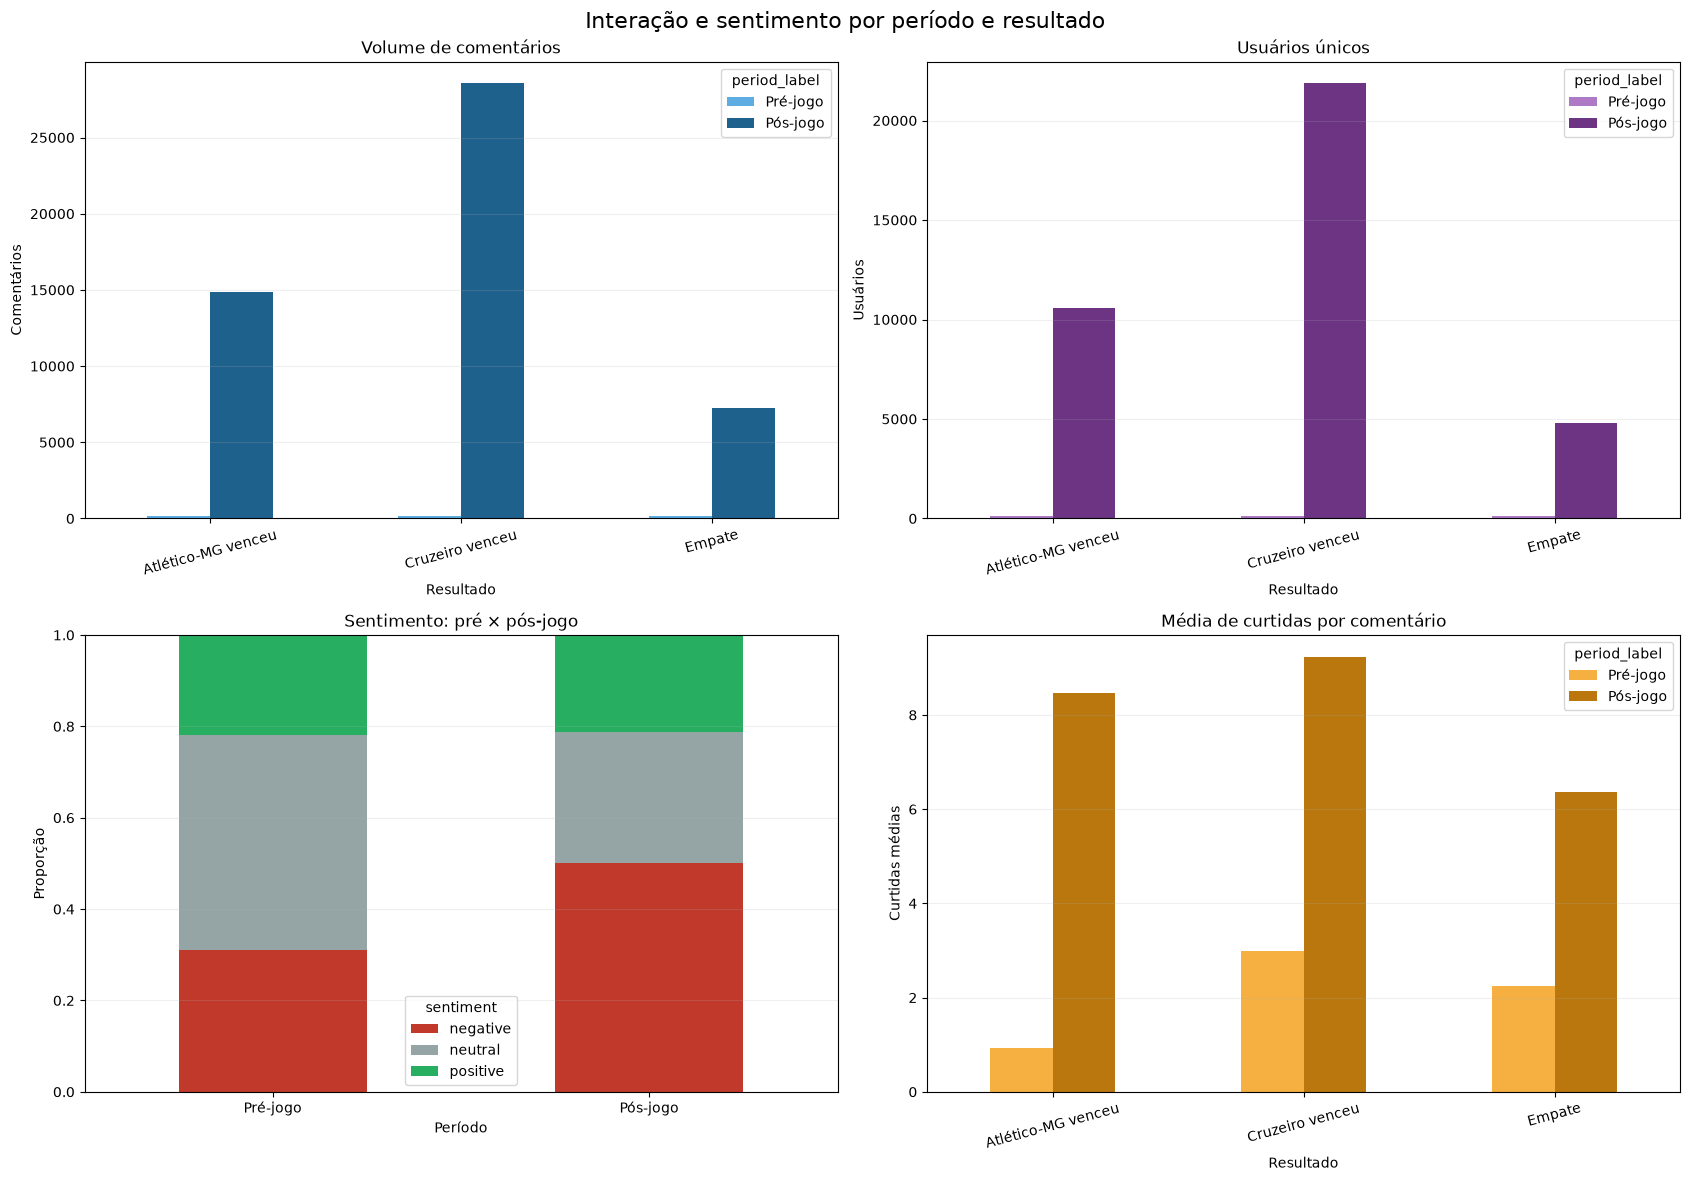

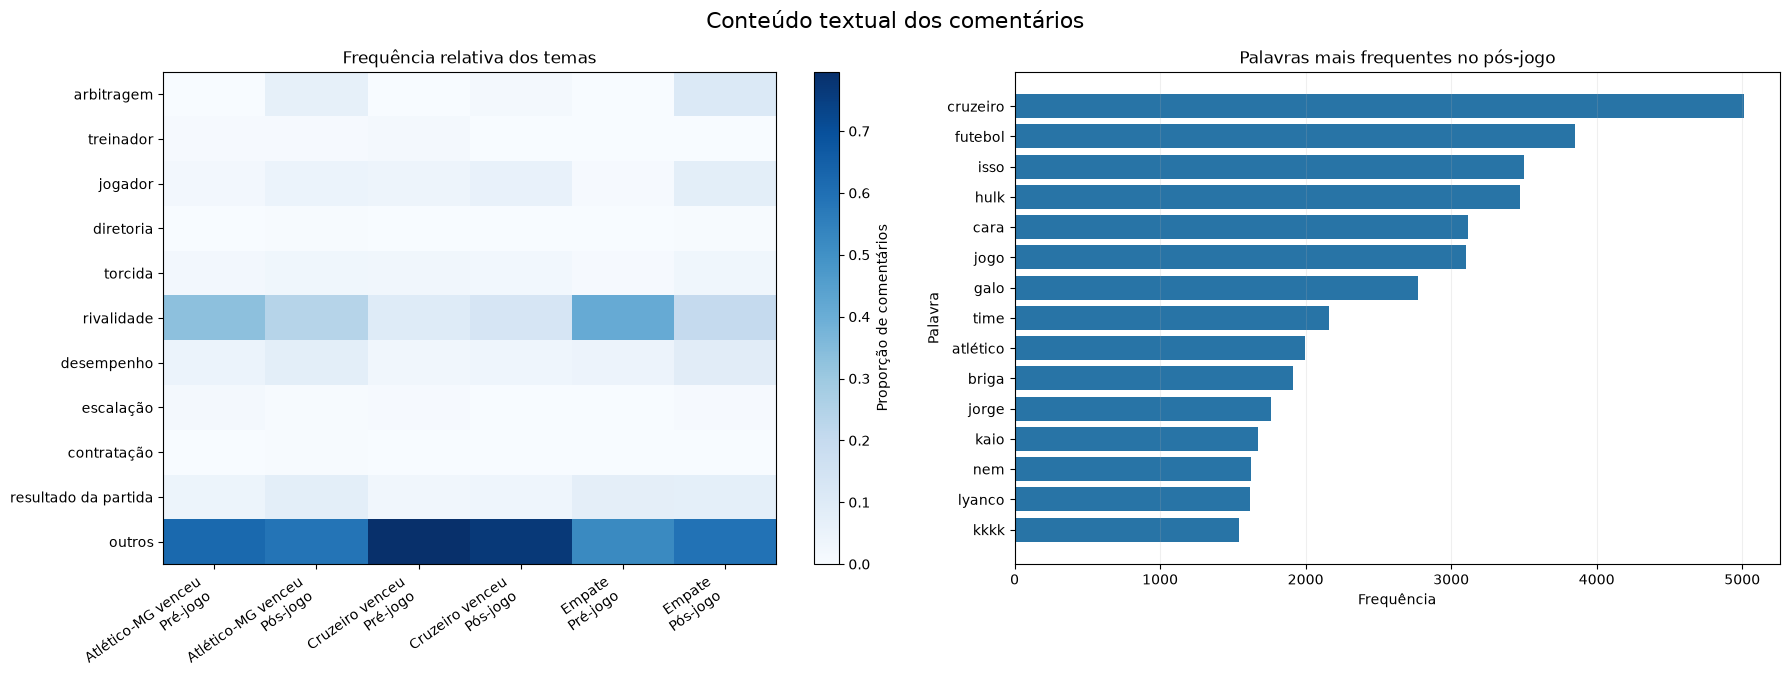

**Entidades:** nenhum alias foi cadastrado em `data/reference/entities.csv`; o gráfico será produzido automaticamente após o preenchimento e a reexecução da Fase 8.

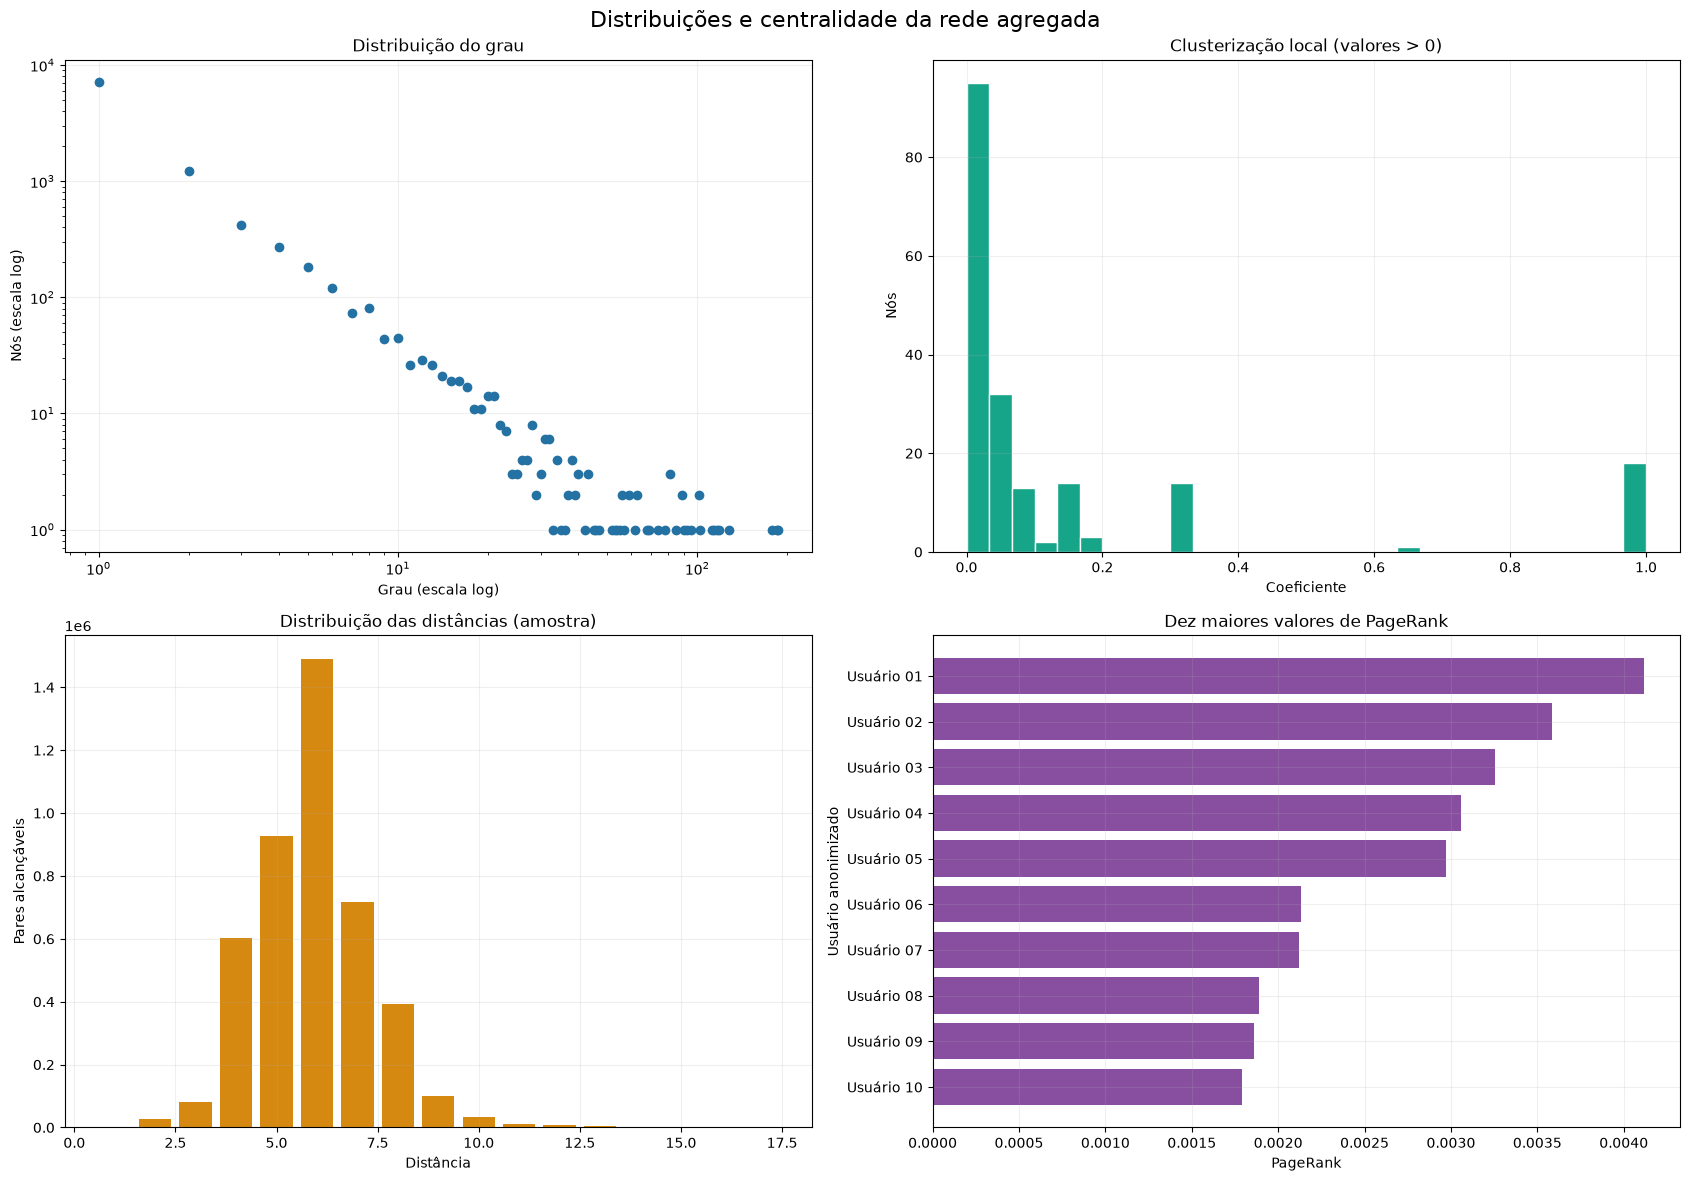

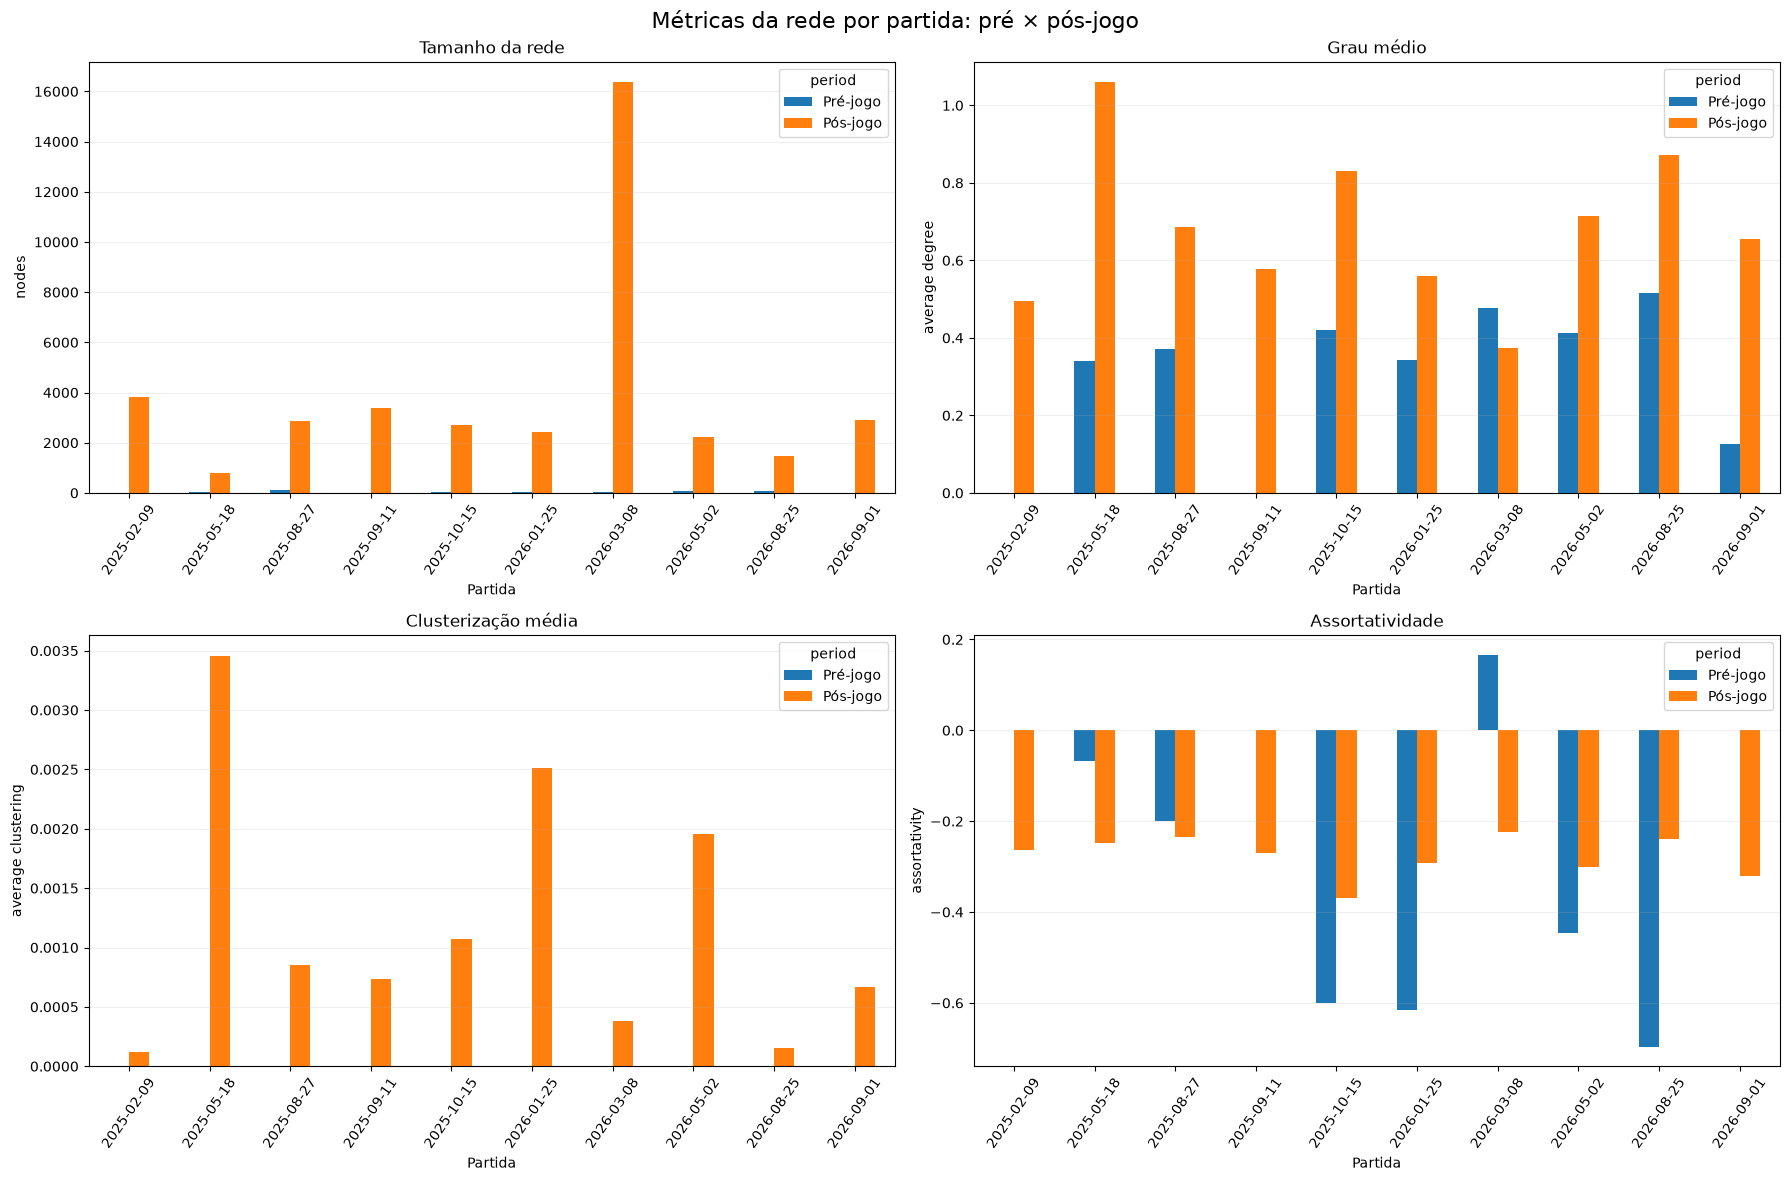


### Síntese da Fase 9

- A negatividade passou de **31.1% no pré-jogo** para **50.0% no pós-jogo**, uma variação de **+19.0 pontos percentuais**.
- O grupo com maior volume foi **Cruzeiro venceu — Pós-jogo**, com **28,550 comentários** e **21,864 usuários únicos**.
- Os gráficos de rede permitem verificar se tamanho, conectividade, clusterização e assortatividade mudam depois de cada resultado.
- As comparações são descritivas: volume desigual de vídeos e comentários, seleção de canais e ausência de identificação clubística dos usuários impedem atribuição causal direta ao placar.
- Antes do artigo, recomenda-se validar manualmente uma amostra estratificada do sentimento e revisar o dicionário de temas e entidades.


Figuras salvas em: /home/dudu/UFV/MineracaoDeDados/outputs/figures


In [22]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

OUTCOME_ORDER = [item for item in ["Atlético-MG venceu", "Cruzeiro venceu", "Empate"] if item in set(phase9["outcome"])]
PERIOD_ORDER = ["Pré-jogo", "Pós-jogo"]
SENTIMENT_COLORS = {"negative": "#c0392b", "neutral": "#95a5a6", "positive": "#27ae60"}

fig, axes = plt.subplots(2, 2, figsize=(17, 12))
comments_plot = comparison.pivot(index="outcome", columns="period_label", values="comments").reindex(OUTCOME_ORDER)
comments_plot.plot(kind="bar", ax=axes[0, 0], color=["#5dade2", "#1f618d"] if len(comments_plot.columns) == 2 else None)
axes[0, 0].set(title="Volume de comentários", xlabel="Resultado", ylabel="Comentários")
axes[0, 0].tick_params(axis="x", rotation=15)
users_plot = comparison.pivot(index="outcome", columns="period_label", values="unique_users").reindex(OUTCOME_ORDER)
users_plot.plot(kind="bar", ax=axes[0, 1], color=["#af7ac5", "#6c3483"] if len(users_plot.columns) == 2 else None)
axes[0, 1].set(title="Usuários únicos", xlabel="Resultado", ylabel="Usuários")
axes[0, 1].tick_params(axis="x", rotation=15)
sentiment_period = (phase9.groupby(["period_label", "sentiment"], observed=True).size().unstack(fill_value=0)
                    .reindex(index=PERIOD_ORDER, columns=["negative", "neutral", "positive"]))
sentiment_period = sentiment_period.div(sentiment_period.sum(axis=1), axis=0)
sentiment_period.plot(kind="bar", stacked=True, ax=axes[1, 0], color=[SENTIMENT_COLORS[item] for item in sentiment_period.columns])
axes[1, 0].set(title="Sentimento: pré × pós-jogo", xlabel="Período", ylabel="Proporção", ylim=(0, 1))
axes[1, 0].tick_params(axis="x", rotation=0)
likes_plot = comparison.pivot(index="outcome", columns="period_label", values="likes_mean").reindex(OUTCOME_ORDER)
likes_plot.plot(kind="bar", ax=axes[1, 1], color=["#f5b041", "#b9770e"] if len(likes_plot.columns) == 2 else None)
axes[1, 1].set(title="Média de curtidas por comentário", xlabel="Resultado", ylabel="Curtidas médias")
axes[1, 1].tick_params(axis="x", rotation=15)
for ax in axes.flat: ax.grid(axis="y", alpha=0.2)
fig.suptitle("Interação e sentimento por período e resultado", fontsize=16)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase9_interactions_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
topic_image = axes[0].imshow(topic_comparison.T.values, aspect="auto", cmap="Blues", vmin=0)
axes[0].set_title("Frequência relativa dos temas")
axes[0].set_xticks(range(len(topic_comparison.index)), [f"{a}\n{b}" for a, b in topic_comparison.index], rotation=35, ha="right")
axes[0].set_yticks(range(len(topic_comparison.columns)), topic_comparison.columns)
fig.colorbar(topic_image, ax=axes[0], label="Proporção de comentários")
post_words = frequent_words(phase9.loc[phase9["period_label"].eq("Pós-jogo")], n=15).sort_values("frequency")
axes[1].barh(post_words["word"], post_words["frequency"], color="#2874a6")
axes[1].set(title="Palavras mais frequentes no pós-jogo", xlabel="Frequência", ylabel="Palavra")
axes[1].grid(axis="x", alpha=0.2)
fig.suptitle("Conteúdo textual dos comentários", fontsize=16)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase9_topics_words.png", dpi=300, bbox_inches="tight")
plt.show()

if not entity_frequency.empty:
    entity_plot = entity_frequency.head(15).sort_values("mentions")
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(entity_plot["entity"], entity_plot["mentions"], color="#7d3c98")
    ax.set(title="Entidades mais mencionadas", xlabel="Menções", ylabel="Entidade")
    ax.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "phase9_entities.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    display(Markdown("**Entidades:** nenhum alias foi cadastrado em `data/reference/entities.csv`; o gráfico será produzido automaticamente após o preenchimento e a reexecução da Fase 8."))

# Distribuições estruturais da rede agregada calculadas na Fase 7.
degree_dist_plot = pd.read_csv(TABLES_DIR / "degree_distribution.csv")
clustering_dist_plot = pd.read_csv(TABLES_DIR / "clustering_distribution.csv")
distance_dist_plot = pd.read_csv(TABLES_DIR / "distance_distribution.csv")
centralities_plot = pd.read_csv(TABLES_DIR / "centralities.csv")
fig, axes = plt.subplots(2, 2, figsize=(17, 12))
positive_degree = degree_dist_plot.loc[(degree_dist_plot["degree"] > 0) & (degree_dist_plot["node_count"] > 0)]
axes[0, 0].loglog(positive_degree["degree"], positive_degree["node_count"], marker="o", linestyle="none", color="#2471a3")
axes[0, 0].set(title="Distribuição do grau", xlabel="Grau (escala log)", ylabel="Nós (escala log)")
nonzero_clustering = clustering_dist_plot.loc[clustering_dist_plot["clustering_coefficient"] > 0, "clustering_coefficient"]
axes[0, 1].hist(nonzero_clustering, bins=30, color="#17a589", edgecolor="white")
axes[0, 1].set(title="Clusterização local (valores > 0)", xlabel="Coeficiente", ylabel="Nós")
axes[1, 0].bar(distance_dist_plot["distance"], distance_dist_plot["pair_count"], color="#d68910")
axes[1, 0].set(title="Distribuição das distâncias (amostra)", xlabel="Distância", ylabel="Pares alcançáveis")
top_pr = centralities_plot.nlargest(10, "pagerank").reset_index(drop=True)
top_pr["pseudonym"] = [f"Usuário {index:02d}" for index in range(1, len(top_pr) + 1)]
axes[1, 1].barh(top_pr["pseudonym"][::-1], top_pr["pagerank"][::-1], color="#884ea0")
axes[1, 1].set(title="Dez maiores valores de PageRank", xlabel="PageRank", ylabel="Usuário anonimizado")
for ax in axes.flat: ax.grid(alpha=0.2)
fig.suptitle("Distribuições e centralidade da rede agregada", fontsize=16)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase9_network_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

match_network = network_comparison.loc[network_comparison["scope"].eq("match")].copy()
match_network["label"] = match_network["match_date"] + " | " + match_network["period"]
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, metric, title in zip(axes.flat, ["nodes", "average_degree", "average_clustering", "assortativity"],
                             ["Tamanho da rede", "Grau médio", "Clusterização média", "Assortatividade"]):
    pivot = match_network.pivot(index="match_date", columns="period", values=metric).sort_index()
    pivot.plot(kind="bar", ax=ax)
    ax.set(title=title, xlabel="Partida", ylabel=metric.replace("_", " "))
    ax.tick_params(axis="x", rotation=55)
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("Métricas da rede por partida: pré × pós-jogo", fontsize=16)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase9_network_comparisons.png", dpi=300, bbox_inches="tight")
plt.show()

pre_negative = phase9.loc[phase9["period_label"].eq("Pré-jogo"), "sentiment"].eq("negative").mean()
post_negative = phase9.loc[phase9["period_label"].eq("Pós-jogo"), "sentiment"].eq("negative").mean()
largest_group = comparison.loc[comparison["comments"].idxmax()]
display(Markdown(f"""
### Síntese da Fase 9

- A negatividade passou de **{pre_negative:.1%} no pré-jogo** para **{post_negative:.1%} no pós-jogo**, uma variação de **{(post_negative-pre_negative)*100:+.1f} pontos percentuais**.
- O grupo com maior volume foi **{largest_group['outcome']} — {largest_group['period_label']}**, com **{int(largest_group['comments']):,} comentários** e **{int(largest_group['unique_users']):,} usuários únicos**.
- Os gráficos de rede permitem verificar se tamanho, conectividade, clusterização e assortatividade mudam depois de cada resultado.
- As comparações são descritivas: volume desigual de vídeos e comentários, seleção de canais e ausência de identificação clubística dos usuários impedem atribuição causal direta ao placar.
- Antes do artigo, recomenda-se validar manualmente uma amostra estratificada do sentimento e revisar o dicionário de temas e entidades.
"""))
print("Figuras salvas em:", FIGURES_DIR.resolve())


# Fase 10 — Entidades relacionadas às partidas

Esta seção integra escalações, técnicos, comissão técnica e diretoria aos comentários. O reconhecimento é condicionado ao `match_id`: uma pessoa só pode ser identificada nas partidas às quais está vinculada na base de referência.

> **Interpretação importante:** o sentimento abaixo é o sentimento do comentário que menciona a entidade, não necessariamente uma opinião dirigida exclusivamente a ela. Os resultados devem ser descritos como associação, e não como causalidade.

In [23]:
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REFERENCE_DIR = Path("data/reference/classicos_atletico_cruzeiro_entidades")
ENTITY_OUTPUT_DIR = Path("outputs/tables")
ENTITY_FIGURE_DIR = Path("outputs/figures")
ENTITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ENTITY_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Use apenas {'high'} para a versão mais conservadora. 'medium' inclui nomes
# populares/abreviados (Dudu, Fred, Pedrinho etc.) e aumenta também falsos positivos.
ALIAS_CONFIDENCES = {"high", "medium"}
MIN_MENTIONS_FOR_DELTA = 20
MIN_PRE_POST_FOR_DELTA = 5

required_reference_files = ["entities_master.csv", "entity_aliases.csv", "match_people.csv", "matches_enriched.csv"]
missing_reference_files = [name for name in required_reference_files if not (REFERENCE_DIR / name).exists()]
if missing_reference_files:
    raise FileNotFoundError(f"Arquivos de referência ausentes: {missing_reference_files}")

entities_master = pd.read_csv(REFERENCE_DIR / "entities_master.csv", dtype="string")
entity_aliases = pd.read_csv(REFERENCE_DIR / "entity_aliases.csv", dtype="string")
match_people = pd.read_csv(REFERENCE_DIR / "match_people.csv", dtype="string")
matches_entities = pd.read_csv(REFERENCE_DIR / "matches_enriched.csv", dtype="string")

# Reaproveita o sentimento já calculado; portanto esta célula não executa o Transformer novamente.
if "comments_nlp" not in globals():
    comments_nlp = pd.read_csv("data/processed/comments_nlp.csv", dtype={"comment_id": "string", "match_id": "string"})
required_comment_columns = {"comment_id", "match_id", "text_original", "comment_period", "sentiment"}
missing_comment_columns = required_comment_columns - set(comments_nlp.columns)
if missing_comment_columns:
    raise ValueError(f"Colunas ausentes em comments_nlp: {sorted(missing_comment_columns)}")

def normalize_entity_text(value):
    value = "" if pd.isna(value) else str(value).casefold()
    value = unicodedata.normalize("NFKD", value)
    return "".join(char for char in value if not unicodedata.combining(char))

# Uma linha pessoa-partida recebe seus aliases e atributos daquela partida.
valid_aliases = entity_aliases.loc[entity_aliases["alias_confidence"].isin(ALIAS_CONFIDENCES)].copy()
valid_aliases["alias_normalized"] = valid_aliases["alias"].map(normalize_entity_text).str.strip()
valid_aliases = valid_aliases.loc[valid_aliases["alias_normalized"].str.len().ge(4)]
people_aliases = match_people.merge(
    valid_aliases[["entity_id", "alias", "alias_normalized", "alias_confidence"]],
    on="entity_id", how="inner", validate="many_to_many"
).drop_duplicates(["match_id", "entity_id", "alias_normalized"])

alias_lookup_by_match = {}
pattern_by_match = {}
for match_id, group in people_aliases.groupby("match_id", sort=False):
    lookup = defaultdict(list)
    for row in group.itertuples(index=False):
        lookup[row.alias_normalized].append(row)
    aliases_ordered = sorted(lookup, key=lambda value: (-len(value), value))
    alias_lookup_by_match[match_id] = lookup
    pattern_by_match[match_id] = re.compile(r"(?<!\w)(?:" + "|".join(map(re.escape, aliases_ordered)) + r")(?!\w)")

mention_records = []
for comment in comments_nlp[list(required_comment_columns)].itertuples(index=False):
    match_id = str(comment.match_id)
    pattern = pattern_by_match.get(match_id)
    if pattern is None:
        continue
    normalized_text = normalize_entity_text(comment.text_original)
    # Retém o alias mais longo por entidade quando nome completo e sobrenome coincidem.
    found_by_entity = {}
    for match in pattern.finditer(normalized_text):
        matched_alias = match.group(0)
        for person in alias_lookup_by_match[match_id][matched_alias]:
            previous = found_by_entity.get(person.entity_id)
            if previous is None or len(matched_alias) > len(previous[0]):
                found_by_entity[person.entity_id] = (matched_alias, person)
    for matched_alias, person in found_by_entity.values():
        mention_records.append({
            "comment_id": comment.comment_id, "match_id": match_id,
            "comment_period": comment.comment_period, "sentiment": comment.sentiment,
            "entity_id": person.entity_id, "canonical_name": person.canonical_name,
            "entity_type": person.entity_type, "role": person.role, "team": person.team,
            "team_result": person.team_result, "participation_status": person.participation_status,
            "matched_alias": matched_alias, "alias_confidence": person.alias_confidence,
        })

entity_mentions = pd.DataFrame(mention_records)
if entity_mentions.empty:
    raise ValueError("Nenhuma entidade foi reconhecida. Verifique aliases, match_id e texto dos comentários.")
entity_mentions.to_csv(ENTITY_OUTPUT_DIR / "entity_mentions.csv", index=False)

entity_summary = (entity_mentions.groupby(["entity_id", "canonical_name", "entity_type", "team"], dropna=False)
    .agg(mentions=("comment_id", "size"), comments=("comment_id", "nunique"), matches=("match_id", "nunique"),
         negative_share=("sentiment", lambda x: x.eq("negative").mean()),
         neutral_share=("sentiment", lambda x: x.eq("neutral").mean()),
         positive_share=("sentiment", lambda x: x.eq("positive").mean()))
    .reset_index().sort_values(["mentions", "canonical_name"], ascending=[False, True]))
entity_summary.to_csv(ENTITY_OUTPUT_DIR / "entity_summary.csv", index=False)

entity_by_match = (entity_mentions.groupby(
    ["match_id", "canonical_name", "entity_type", "role", "team", "team_result", "comment_period", "sentiment"], dropna=False)
    .size().rename("mentions").reset_index())
entity_by_match.to_csv(ENTITY_OUTPUT_DIR / "entity_mentions_by_match.csv", index=False)

print(f"Entidades cadastradas: {entities_master['entity_id'].nunique():,}")
print(f"Aliases utilizados: {people_aliases['alias_normalized'].nunique():,}")
print(f"Comentários com entidade: {entity_mentions['comment_id'].nunique():,} de {comments_nlp['comment_id'].nunique():,}")
print(f"Menções pessoa-comentário: {len(entity_mentions):,}")
entity_summary_display = entity_summary.head(20).copy()
for column in ["negative_share", "neutral_share", "positive_share"]:
    entity_summary_display[column] = entity_summary_display[column].map(lambda value: f"{value:.1%}")
display(entity_summary_display)


Entidades cadastradas: 132
Aliases utilizados: 169
Comentários com entidade: 11,245 de 58,910
Menções pessoa-comentário: 12,971


,entity_id,canonical_name,entity_type,team,mentions,comments,matches,negative_share,neutral_share,positive_share
34,player_hulk,Hulk,player,Atlético-MG,3517,3517,7,54.7%,28.8%,16.4%
41,player_kaio_jorge,Kaio Jorge,player,Cruzeiro,1626,1626,9,65.2%,22.2%,12.6%
18,player_cassio,Cássio,player,Cruzeiro,1068,1068,7,54.9%,30.2%,14.9%
24,player_everson,Everson,player,Atlético-MG,884,884,10,75.1%,16.1%,8.8%
50,player_lyanco,Lyanco,player,Atlético-MG,882,882,4,76.3%,18.0%,5.7%
29,player_gabriel_barbosa,Gabriel Barbosa,player,Cruzeiro,735,735,5,57.4%,23.0%,19.6%
25,player_fabricio_bruno,Fabrício Bruno,player,Cruzeiro,687,687,9,55.2%,26.3%,18.5%
31,player_gerson,Gerson,player,Cruzeiro,383,383,5,53.8%,32.4%,13.8%
28,player_fred,Fred,player,Atlético-MG,320,320,2,38.8%,25.9%,35.3%
21,player_dudu,Dudu,player,Atlético-MG,306,306,4,57.5%,32.0%,10.5%


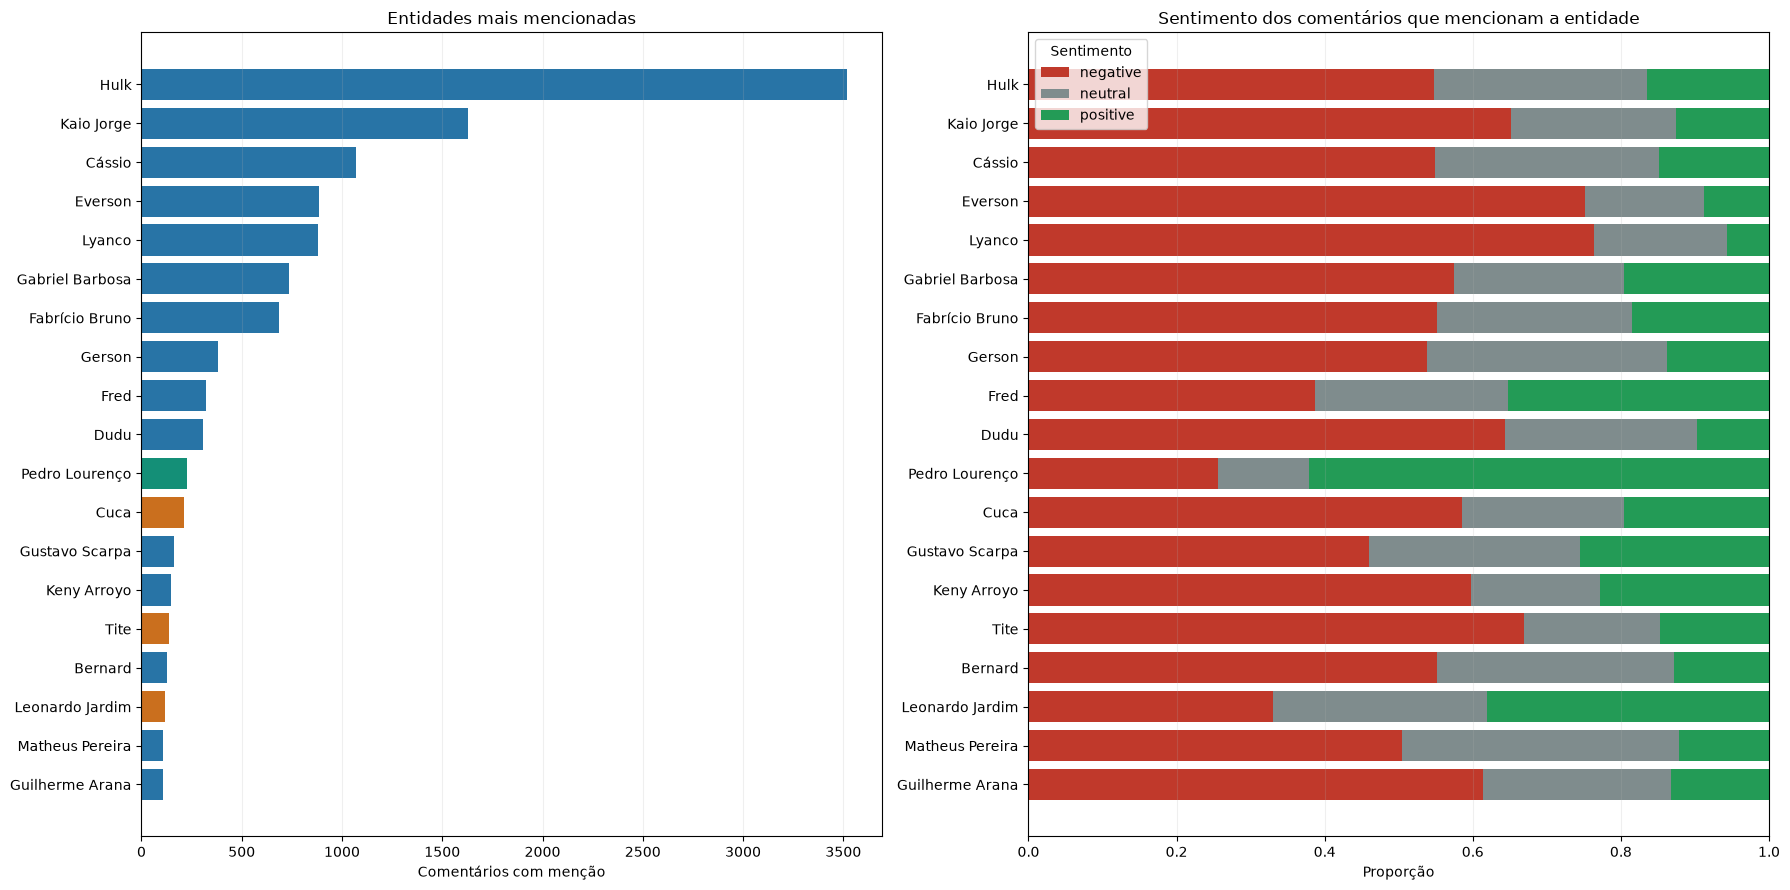

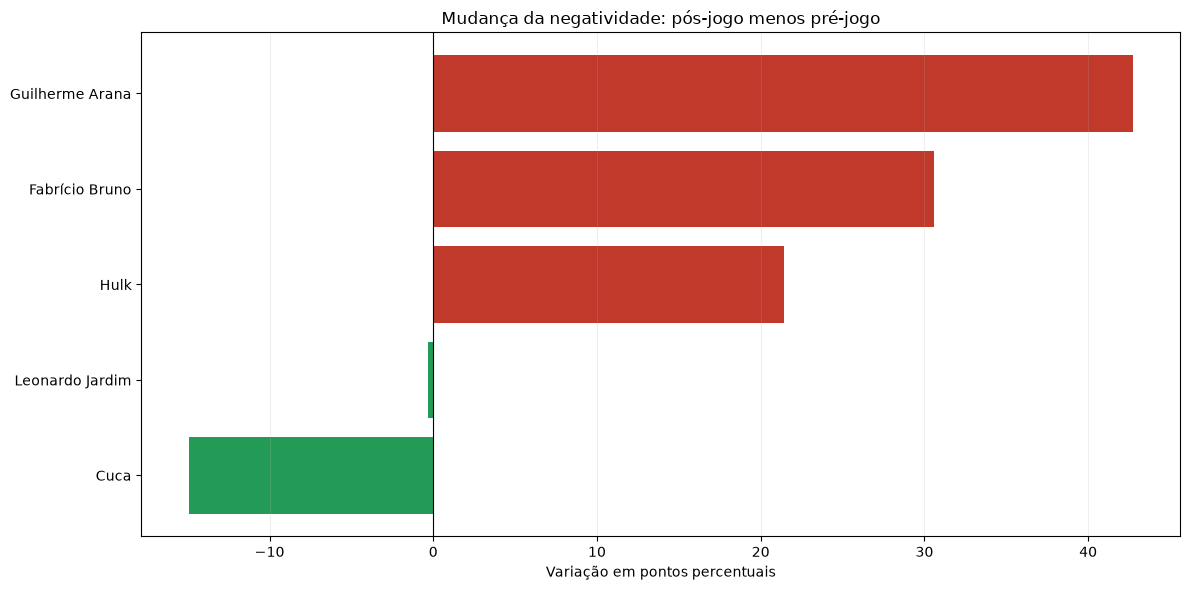

,entity_id,canonical_name,entity_type,team,comments_post_game,comments_pre_game,negative_share_post_game,negative_share_pre_game,positive_share_post_game,positive_share_pre_game,negative_delta_pp,positive_delta_pp
32,player_guilherme_arana,Guilherme Arana,player,Atlético-MG,97.0,9.0,0.649485,0.222222,0.113402,0.333333,+42.7,-22.0
25,player_fabricio_bruno,Fabrício Bruno,player,Cruzeiro,678.0,8.0,0.556047,0.250000,0.182891,0.375000,+30.6,-19.2
34,player_hulk,Hulk,player,Atlético-MG,3510.0,6.0,0.547863,0.333333,0.164103,0.333333,+21.5,-16.9
4,coach_leonardo_jardim,Leonardo Jardim,coach,Cruzeiro,109.0,9.0,0.330275,0.333333,0.366972,0.555556,-0.3,-18.9
1,coach_cuca,Cuca,coach,Atlético-MG,199.0,11.0,0.577889,0.727273,0.195980,0.181818,-14.9,+1.4


In [24]:
# Rankings e composição do sentimento nas entidades mais mencionadas.
type_labels = {"player": "Jogador", "coach": "Técnico", "technical_staff": "Comissão técnica", "management": "Diretoria"}
type_colors = {"player": "#2874a6", "coach": "#ca6f1e", "technical_staff": "#7d3c98", "management": "#148f77"}
top_entities = entity_summary.head(20).sort_values("mentions")
sentiment_order = ["negative", "neutral", "positive"]
sentiment_colors = {"negative": "#c0392b", "neutral": "#7f8c8d", "positive": "#239b56"}
sentiment_entity = (entity_mentions.loc[entity_mentions["entity_id"].isin(top_entities["entity_id"])]
    .groupby(["canonical_name", "sentiment"]).size().unstack(fill_value=0).reindex(columns=sentiment_order, fill_value=0))
sentiment_entity = sentiment_entity.div(sentiment_entity.sum(axis=1), axis=0).loc[top_entities["canonical_name"]]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
axes[0].barh(top_entities["canonical_name"], top_entities["mentions"], color=top_entities["entity_type"].map(type_colors))
axes[0].set(title="Entidades mais mencionadas", xlabel="Comentários com menção", ylabel="")
left = np.zeros(len(sentiment_entity))
for sentiment in sentiment_order:
    values = sentiment_entity[sentiment].to_numpy()
    axes[1].barh(sentiment_entity.index, values, left=left, color=sentiment_colors[sentiment], label=sentiment)
    left += values
axes[1].set(title="Sentimento dos comentários que mencionam a entidade", xlabel="Proporção", ylabel="", xlim=(0, 1))
axes[1].legend(title="Sentimento")
for ax in axes: ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
fig.savefig(ENTITY_FIGURE_DIR / "entities_rank_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

# Diferença pós - pré por entidade; exige volume mínimo nos dois períodos.
period_entity = (entity_mentions.loc[entity_mentions["comment_period"].isin(["pre_game", "post_game"])]
    .groupby(["entity_id", "canonical_name", "entity_type", "team", "comment_period"])
    .agg(comments=("comment_id", "nunique"), negative_share=("sentiment", lambda x: x.eq("negative").mean()),
         positive_share=("sentiment", lambda x: x.eq("positive").mean())).reset_index())
period_wide = period_entity.pivot(index=["entity_id", "canonical_name", "entity_type", "team"], columns="comment_period")
period_wide.columns = [f"{metric}_{period}" for metric, period in period_wide.columns]
period_wide = period_wide.reset_index()
for period in ["pre_game", "post_game"]:
    if f"comments_{period}" not in period_wide: period_wide[f"comments_{period}"] = 0
    if f"negative_share_{period}" not in period_wide: period_wide[f"negative_share_{period}"] = np.nan
    if f"positive_share_{period}" not in period_wide: period_wide[f"positive_share_{period}"] = np.nan
period_wide["negative_delta_pp"] = 100 * (period_wide["negative_share_post_game"] - period_wide["negative_share_pre_game"])
period_wide["positive_delta_pp"] = 100 * (period_wide["positive_share_post_game"] - period_wide["positive_share_pre_game"])
period_wide.to_csv(ENTITY_OUTPUT_DIR / "entity_pre_post_delta.csv", index=False)
eligible_delta = period_wide.loc[(period_wide["comments_pre_game"] >= MIN_PRE_POST_FOR_DELTA) &
                                 (period_wide["comments_post_game"] >= MIN_PRE_POST_FOR_DELTA) &
                                 ((period_wide["comments_pre_game"] + period_wide["comments_post_game"]) >= MIN_MENTIONS_FOR_DELTA)].copy()
delta_plot = pd.concat([eligible_delta.nsmallest(8, "negative_delta_pp"), eligible_delta.nlargest(8, "negative_delta_pp")]).drop_duplicates("entity_id").sort_values("negative_delta_pp")
if not delta_plot.empty:
    colors = np.where(delta_plot["negative_delta_pp"] >= 0, "#c0392b", "#239b56")
    fig, ax = plt.subplots(figsize=(12, max(6, 0.45 * len(delta_plot))))
    ax.barh(delta_plot["canonical_name"], delta_plot["negative_delta_pp"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set(title="Mudança da negatividade: pós-jogo menos pré-jogo", xlabel="Variação em pontos percentuais", ylabel="")
    ax.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    fig.savefig(ENTITY_FIGURE_DIR / "entities_pre_post_negative_delta.png", dpi=300, bbox_inches="tight")
    plt.show()
eligible_delta_display = eligible_delta.sort_values("negative_delta_pp", ascending=False).head(20).copy()
for column in ["negative_delta_pp", "positive_delta_pp"]:
    eligible_delta_display[column] = eligible_delta_display[column].map(lambda value: f"{value:+.1f}")
display(eligible_delta_display)


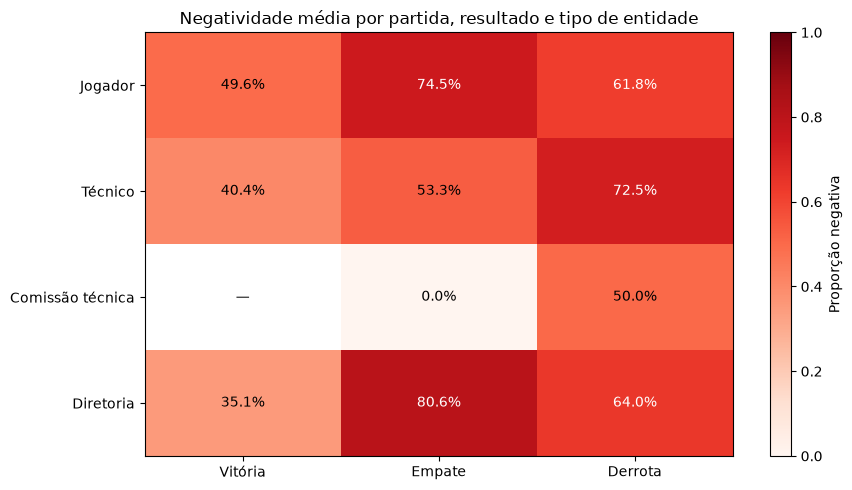

,team_result,entity_type,matches,mean_mentions_per_match,mean_negative_share,mean_positive_share
0,draw,coach,3,8.3,53.3%,28.1%
1,draw,management,3,4.3,80.6%,0.0%
2,draw,player,3,523.3,74.5%,9.9%
3,draw,technical_staff,1,1.0,0.0%,100.0%
4,loss,coach,6,52.5,72.5%,9.2%
5,loss,management,4,14.5,64.0%,10.1%
6,loss,player,7,833.9,61.8%,13.6%
7,loss,technical_staff,1,2.0,50.0%,0.0%
8,win,coach,6,32.5,40.4%,38.7%
9,win,management,3,54.7,35.1%,51.0%


,team_result,participation_status,matches,mean_mentions,mean_negative_share,mean_positive_share
0,draw,starter,3,465.000000,0.741316,0.099541
1,draw,substitute_used,3,58.333333,0.783049,0.114659
2,loss,starter,7,817.428571,0.616011,0.137861
3,loss,substitute_used,7,16.428571,0.720770,0.062075
4,win,starter,7,653.285714,0.489440,0.231159
5,win,substitute_used,7,31.142857,0.561657,0.186061


In [25]:
# Resultado da equipe × grupo profissional. A unidade é primeiro a partida,
# para que uma partida com muito mais comentários não domine a comparação.
role_result_match = (entity_mentions.groupby(["match_id", "team_result", "entity_type"])
    .agg(mentions=("comment_id", "size"), comments=("comment_id", "nunique"),
         negative_share=("sentiment", lambda x: x.eq("negative").mean()),
         positive_share=("sentiment", lambda x: x.eq("positive").mean())).reset_index())
role_result = (role_result_match.groupby(["team_result", "entity_type"])
    .agg(matches=("match_id", "nunique"), mean_mentions_per_match=("mentions", "mean"),
         mean_negative_share=("negative_share", "mean"), mean_positive_share=("positive_share", "mean")).reset_index())
role_result.to_csv(ENTITY_OUTPUT_DIR / "entity_type_by_team_result.csv", index=False)

result_order = ["win", "draw", "loss"]
type_order = ["player", "coach", "technical_staff", "management"]
heat = role_result.pivot(index="entity_type", columns="team_result", values="mean_negative_share").reindex(index=type_order, columns=result_order)
fig, ax = plt.subplots(figsize=(9, 5))
image = ax.imshow(heat.to_numpy(dtype=float), cmap="Reds", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(result_order)), ["Vitória", "Empate", "Derrota"])
ax.set_yticks(range(len(type_order)), [type_labels[item] for item in type_order])
for row in range(len(type_order)):
    for column in range(len(result_order)):
        value = heat.iloc[row, column]
        ax.text(column, row, "—" if pd.isna(value) else f"{value:.1%}", ha="center", va="center", color="white" if pd.notna(value) and value > .55 else "black")
ax.set_title("Negatividade média por partida, resultado e tipo de entidade")
fig.colorbar(image, ax=ax, label="Proporção negativa")
fig.tight_layout()
fig.savefig(ENTITY_FIGURE_DIR / "entity_type_result_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
role_result_display = role_result.copy()
role_result_display["mean_mentions_per_match"] = role_result_display["mean_mentions_per_match"].map(lambda value: f"{value:.1f}")
for column in ["mean_negative_share", "mean_positive_share"]:
    role_result_display[column] = role_result_display[column].map(lambda value: f"{value:.1%}")
display(role_result_display)

# Titulares versus substitutos utilizados.
player_participation = (entity_mentions.loc[entity_mentions["entity_type"].eq("player")]
    .groupby(["match_id", "team_result", "participation_status"], dropna=False)
    .agg(mentions=("comment_id", "size"), negative_share=("sentiment", lambda x: x.eq("negative").mean()),
         positive_share=("sentiment", lambda x: x.eq("positive").mean())).reset_index())
player_participation.to_csv(ENTITY_OUTPUT_DIR / "player_participation_mentions.csv", index=False)
display(player_participation.groupby(["team_result", "participation_status"]).agg(
    matches=("match_id", "nunique"), mean_mentions=("mentions", "mean"),
    mean_negative_share=("negative_share", "mean"), mean_positive_share=("positive_share", "mean")).reset_index())


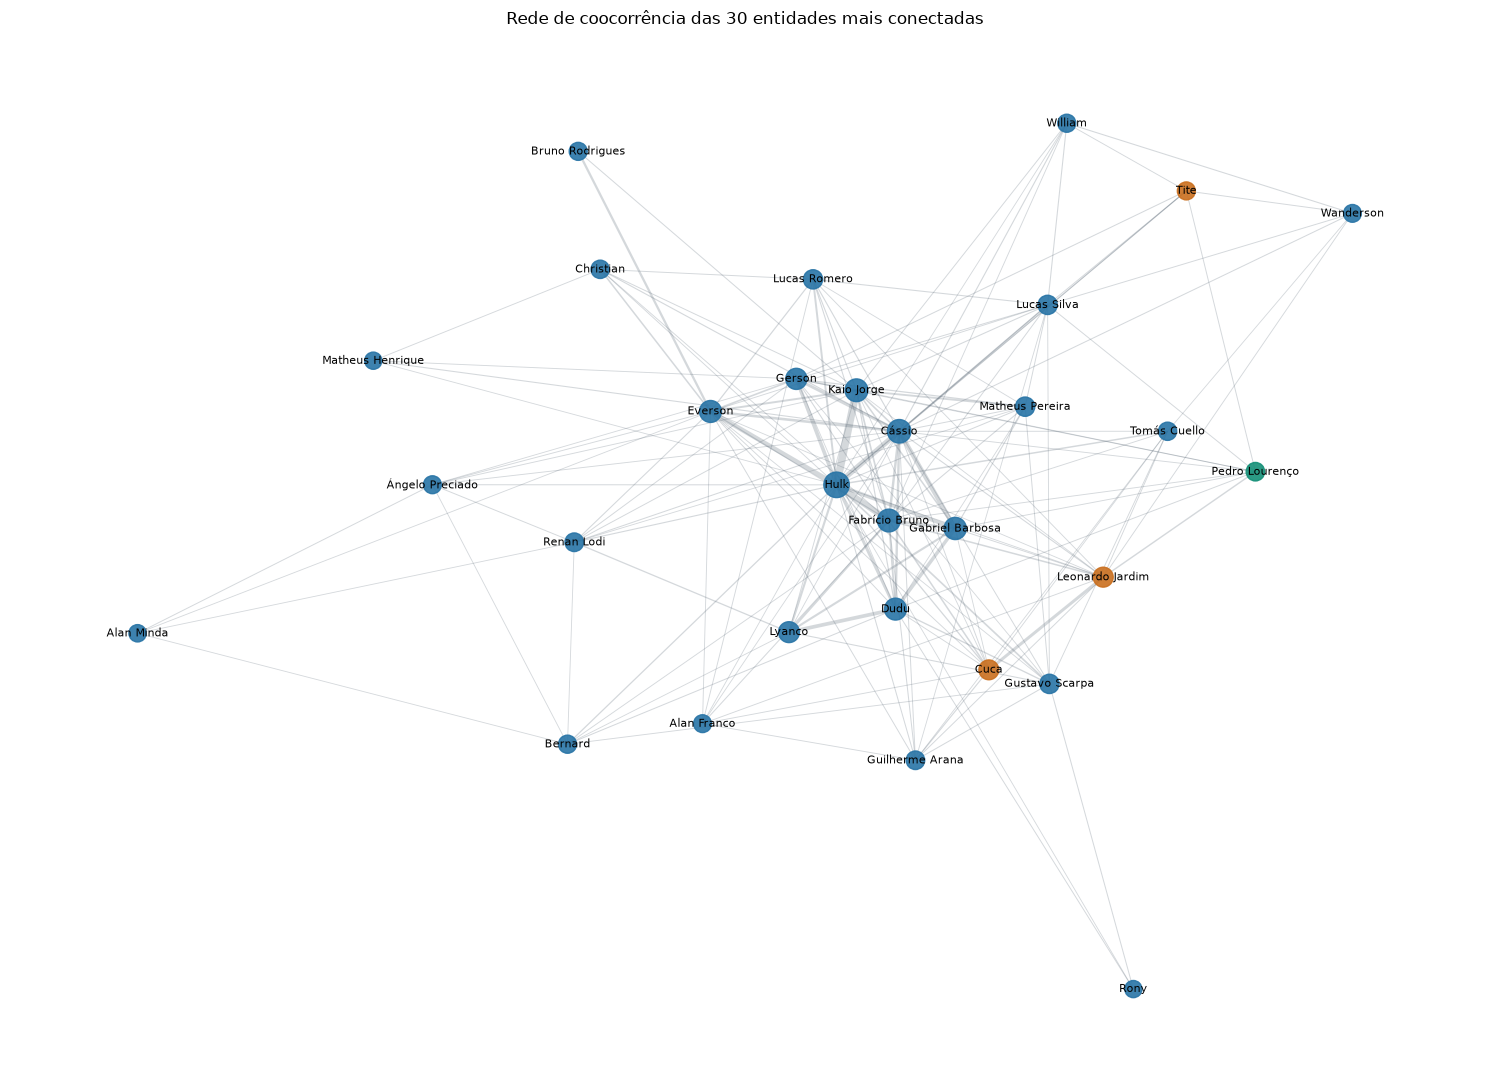


### Síntese das entidades

- **Hulk** foi a entidade mais mencionada, em **3,517 comentários** distribuídos por **7 partida(s)**.
- Entre entidades com pelo menos 20 menções, **Iván Román** teve a maior proporção de comentários negativos (**95.7%**).
- Houve menção a integrantes da **diretoria em 233 comentários** e a outros membros da **comissão técnica em 3**. O baixo volume da comissão recomenda análise qualitativa, não comparação percentual isolada.
- O gráfico pré/pós exige ao menos 5 comentários em cada período; entidades abaixo desse limite permanecem no CSV, mas não aparecem no ranking visual.
- Aliases usados: **high, medium**. Para testar robustez contra nomes ambíguos, execute novamente com `ALIAS_CONFIDENCES = high` e compare os CSVs.
- A rede de coocorrência representa associação discursiva entre pessoas, sendo diferente da rede de respostas entre usuários construída anteriormente.


Tabelas salvas em: /home/dudu/UFV/MineracaoDeDados/outputs/tables
Figuras salvas em: /home/dudu/UFV/MineracaoDeDados/outputs/figures
Rede para Gephi salva em: outputs/networks/entity_cooccurrence.gexf


In [26]:
# Rede de coocorrência: duas entidades se conectam quando são mencionadas no mesmo comentário.
pair_counter = Counter()
pair_negative = defaultdict(list)
for (_, _), group in entity_mentions.groupby(["match_id", "comment_id"]):
    ids = sorted(group["entity_id"].unique())
    is_negative = group["sentiment"].iloc[0] == "negative"
    for source, target in combinations(ids, 2):
        pair_counter[(source, target)] += 1
        pair_negative[(source, target)].append(is_negative)

cooccurrence_edges = pd.DataFrame([
    {"source": source, "target": target, "weight": weight,
     "negative_share": np.mean(pair_negative[(source, target)])}
    for (source, target), weight in pair_counter.items()
]).sort_values("weight", ascending=False) if pair_counter else pd.DataFrame(columns=["source", "target", "weight", "negative_share"])
cooccurrence_edges.to_csv(ENTITY_OUTPUT_DIR / "entity_cooccurrence_edges.csv", index=False)

node_attributes = (match_people[["entity_id", "canonical_name", "entity_type", "team"]]
    .drop_duplicates("entity_id").set_index("entity_id").to_dict("index"))
co_graph = nx.Graph()
for row in cooccurrence_edges.loc[cooccurrence_edges["weight"] >= 3].itertuples(index=False):
    co_graph.add_edge(row.source, row.target, weight=int(row.weight), negative_share=float(row.negative_share))
nx.set_node_attributes(co_graph, {node: node_attributes.get(node, {}) for node in co_graph.nodes})
nx.write_gexf(co_graph, "outputs/networks/entity_cooccurrence.gexf")

if co_graph.number_of_nodes():
    weighted_degree = dict(co_graph.degree(weight="weight"))
    selected_nodes = sorted(weighted_degree, key=weighted_degree.get, reverse=True)[:30]
    view = co_graph.subgraph(selected_nodes).copy()
    position = nx.spring_layout(view, seed=42, weight="weight", k=1.2 / np.sqrt(max(1, view.number_of_nodes())))
    figure, axis = plt.subplots(figsize=(15, 11))
    edge_weights = [view[u][v]["weight"] for u, v in view.edges]
    max_edge = max(edge_weights, default=1)
    nx.draw_networkx_edges(view, position, width=[0.5 + 5 * value / max_edge for value in edge_weights], alpha=.25, edge_color="#566573", ax=axis)
    nx.draw_networkx_nodes(view, position, node_size=[120 + 8 * np.sqrt(weighted_degree[node]) for node in view],
        node_color=[type_colors.get(view.nodes[node].get("entity_type"), "#999999") for node in view], alpha=.9, ax=axis)
    labels = {node: view.nodes[node].get("canonical_name", node) for node in view}
    nx.draw_networkx_labels(view, position, labels=labels, font_size=8, ax=axis)
    axis.set_title("Rede de coocorrência das 30 entidades mais conectadas")
    axis.axis("off")
    figure.tight_layout()
    figure.savefig(ENTITY_FIGURE_DIR / "entity_cooccurrence_network.png", dpi=300, bbox_inches="tight")
    plt.show()

top_person = entity_summary.iloc[0]
top_negative = entity_summary.loc[entity_summary["mentions"] >= MIN_MENTIONS_FOR_DELTA].sort_values("negative_share", ascending=False).iloc[0]
management_mentions = int(entity_mentions.loc[entity_mentions["entity_type"].eq("management"), "comment_id"].nunique())
staff_mentions = int(entity_mentions.loc[entity_mentions["entity_type"].eq("technical_staff"), "comment_id"].nunique())
display(Markdown(f"""
### Síntese das entidades

- **{top_person['canonical_name']}** foi a entidade mais mencionada, em **{int(top_person['comments']):,} comentários** distribuídos por **{int(top_person['matches'])} partida(s)**.
- Entre entidades com pelo menos {MIN_MENTIONS_FOR_DELTA} menções, **{top_negative['canonical_name']}** teve a maior proporção de comentários negativos (**{top_negative['negative_share']:.1%}**).
- Houve menção a integrantes da **diretoria em {management_mentions:,} comentários** e a outros membros da **comissão técnica em {staff_mentions:,}**. O baixo volume da comissão recomenda análise qualitativa, não comparação percentual isolada.
- O gráfico pré/pós exige ao menos {MIN_PRE_POST_FOR_DELTA} comentários em cada período; entidades abaixo desse limite permanecem no CSV, mas não aparecem no ranking visual.
- Aliases usados: **{', '.join(sorted(ALIAS_CONFIDENCES))}**. Para testar robustez contra nomes ambíguos, execute novamente com `ALIAS_CONFIDENCES = {'high'}` e compare os CSVs.
- A rede de coocorrência representa associação discursiva entre pessoas, sendo diferente da rede de respostas entre usuários construída anteriormente.
"""))
print("Tabelas salvas em:", ENTITY_OUTPUT_DIR.resolve())
print("Figuras salvas em:", ENTITY_FIGURE_DIR.resolve())
print("Rede para Gephi salva em: outputs/networks/entity_cooccurrence.gexf")


## Nuvem de palavras mais frequentes

O tamanho de cada palavra é proporcional à sua frequência nos comentários. Stopwords, URLs e termos muito genéricos da coleta são removidos para destacar o vocabulário relevante. Além da visão geral, as nuvens segmentadas permitem comparar o discurso por resultado do Atlético e pelo horário real do comentário.

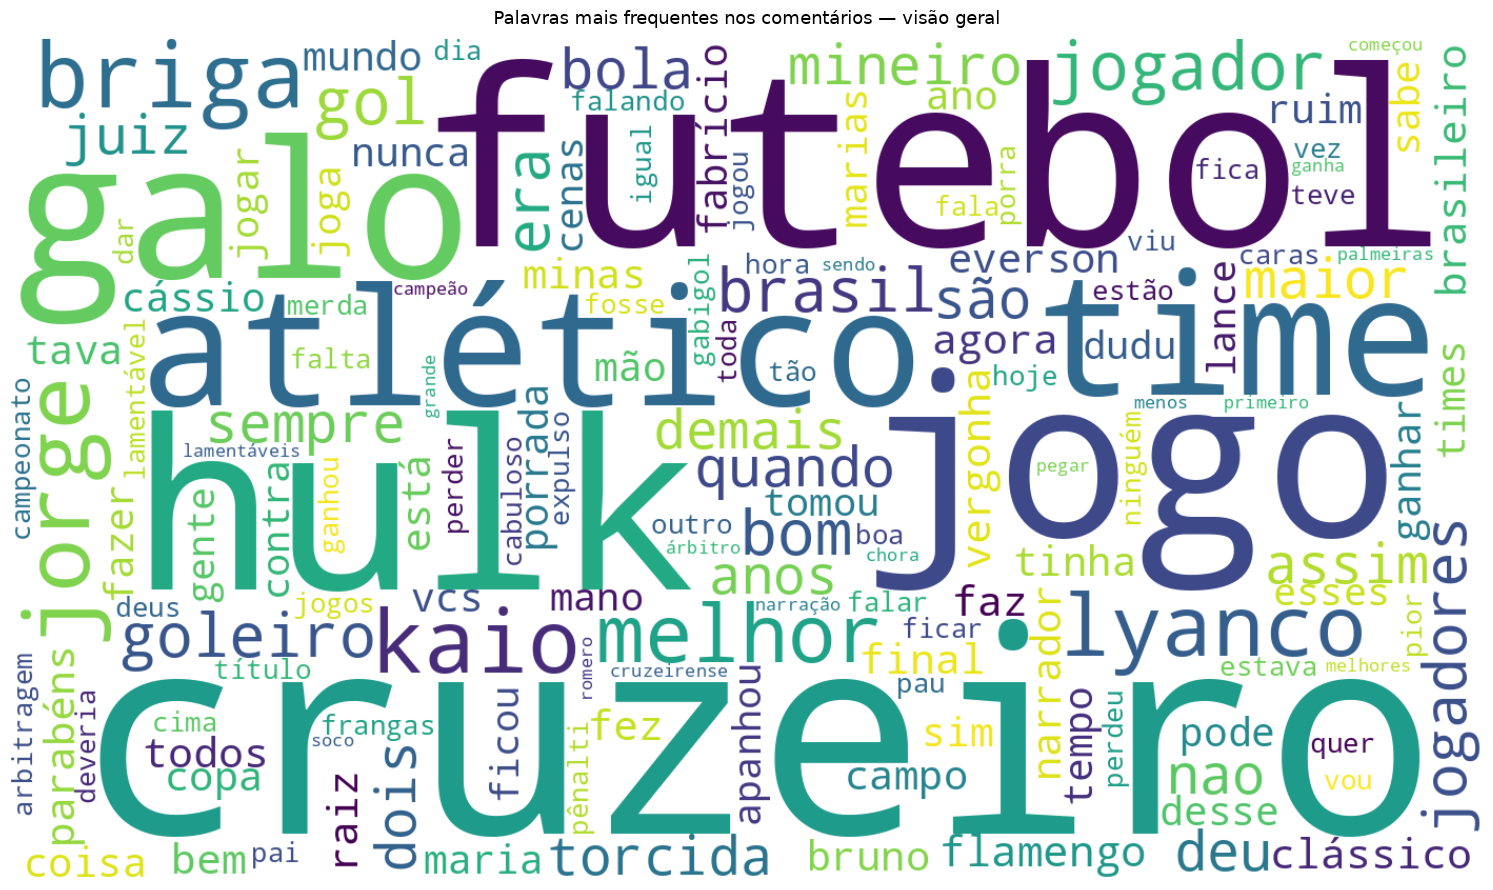

,word,frequency
0,cruzeiro,5826
1,futebol,4258
2,hulk,3923
3,jogo,3539
4,galo,3165
5,time,2400
6,atlético,2250
7,briga,2086
8,jorge,2066
9,kaio,1935


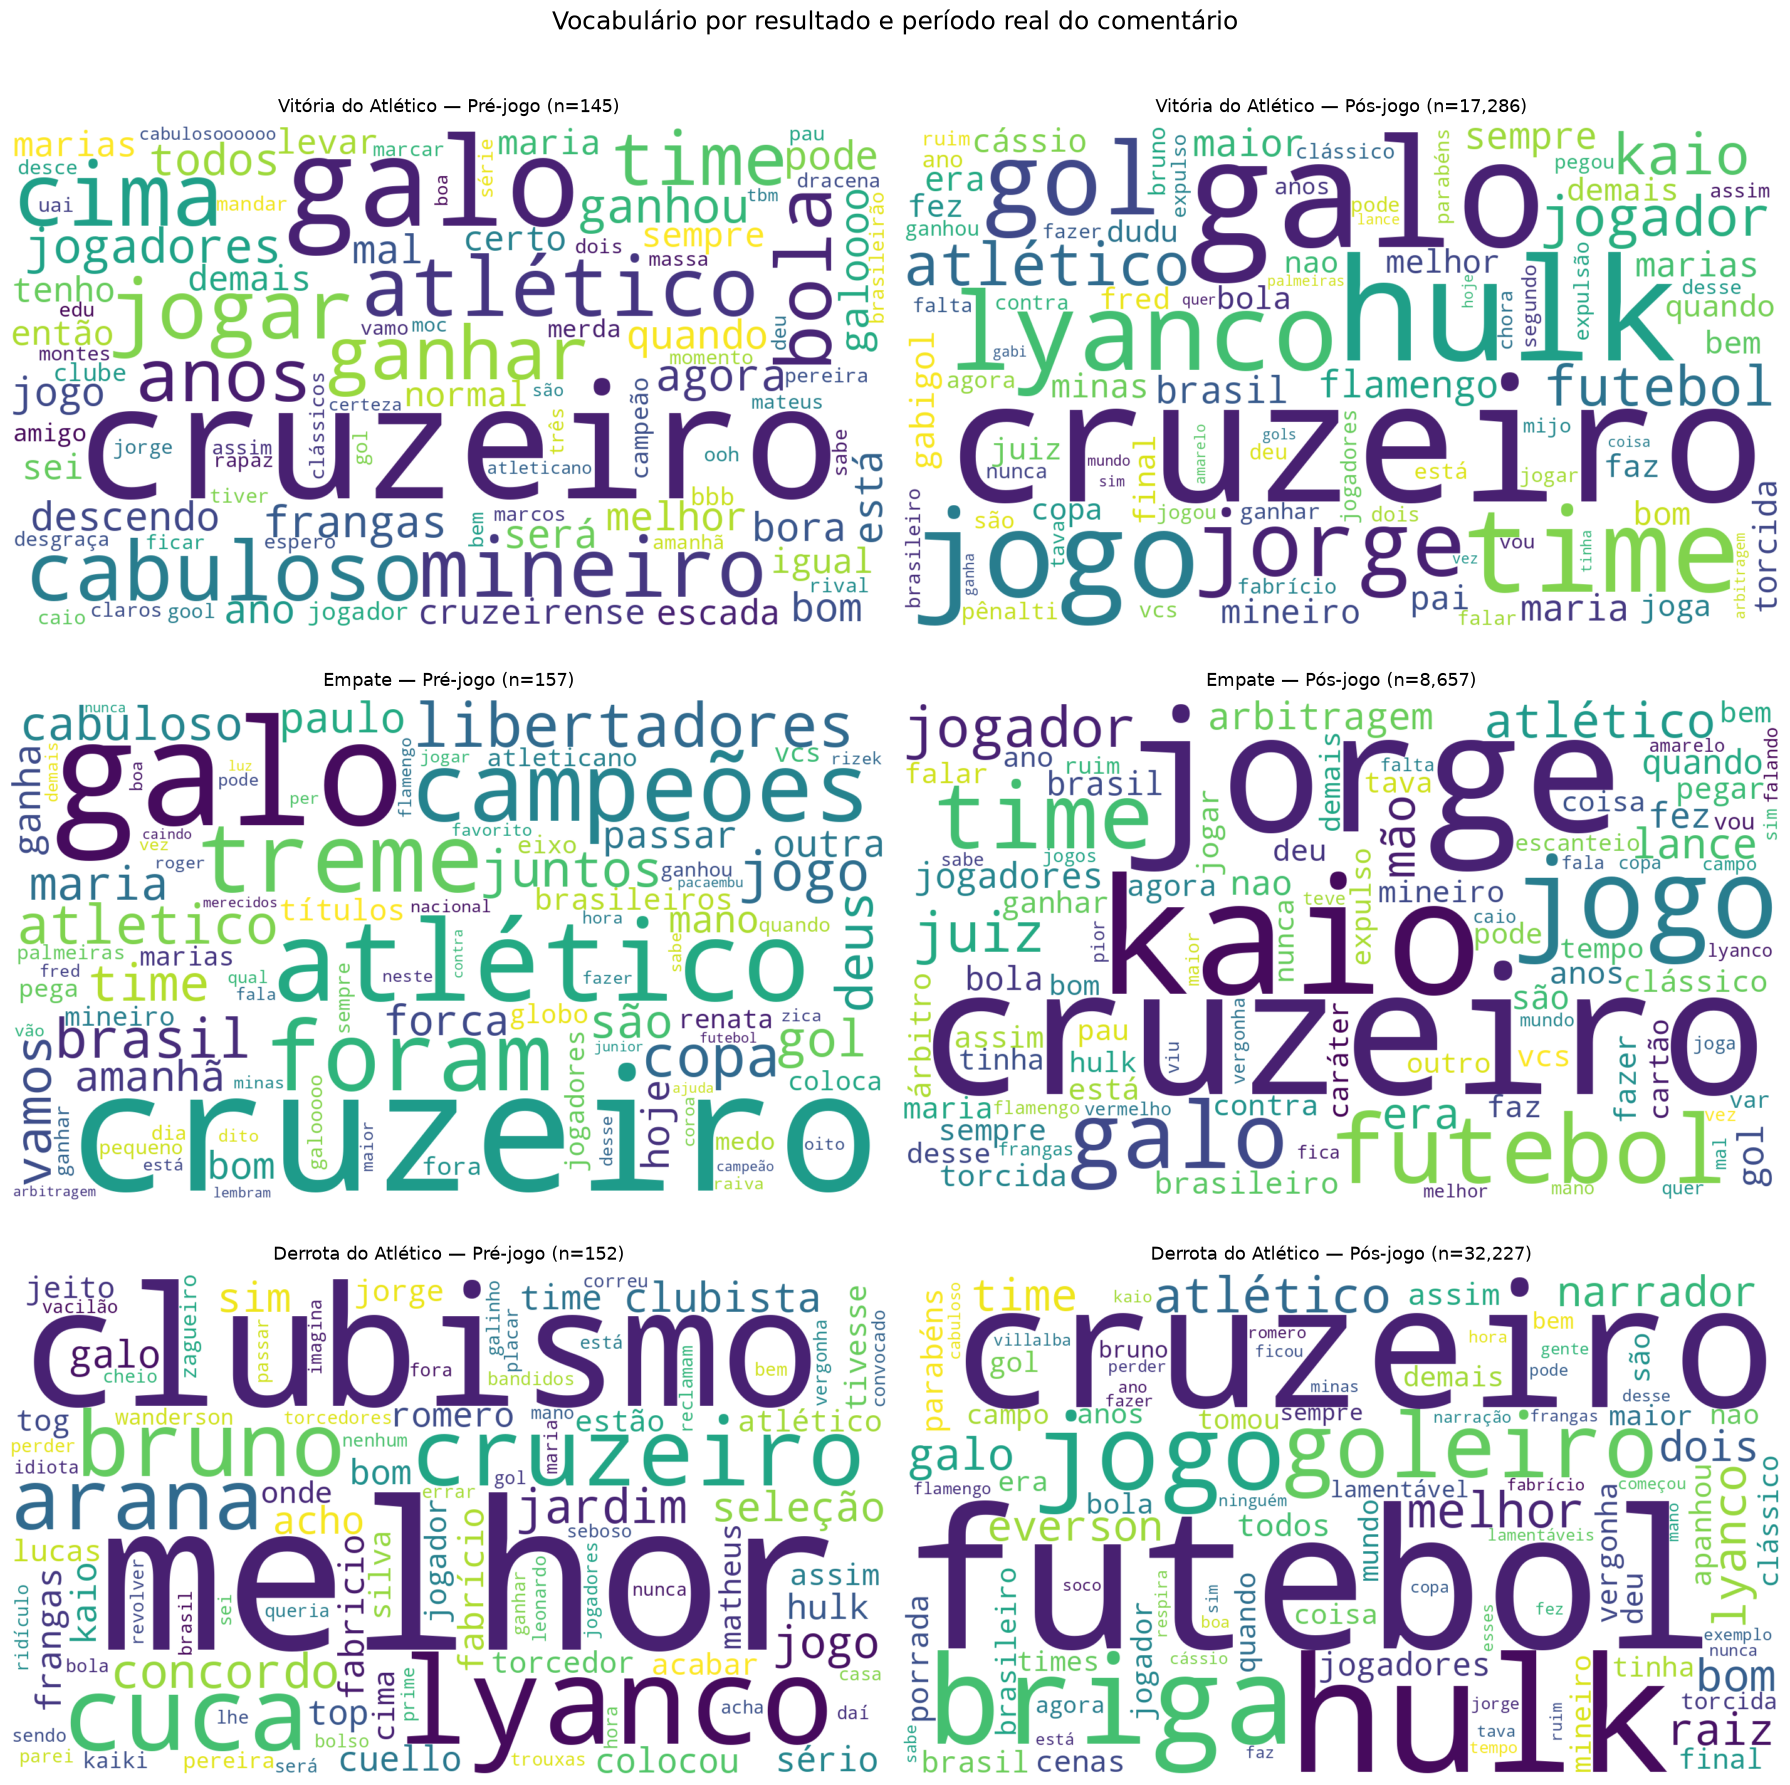

Nuvens salvas em: /home/dudu/UFV/MineracaoDeDados/outputs/figures


In [27]:
from collections import Counter
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
from IPython.display import display

WORDCLOUD_DIR = Path("outputs/figures")
WORDCLOUD_TABLE_DIR = Path("outputs/tables")
WORDCLOUD_DIR.mkdir(parents=True, exist_ok=True)
WORDCLOUD_TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Termos sem valor analítico. Acrescente palavras nesta lista caso ainda apareça ruído.
PORTUGUESE_STOPWORDS = {
    "a", "à", "ao", "aos", "aqui", "as", "até", "com", "como", "da", "das", "de", "dela",
    "dele", "deles", "depois", "do", "dos", "e", "é", "ela", "ele", "eles", "em", "essa",
    "esse", "esta", "este", "eu", "foi", "já", "lá", "mais", "mas", "me", "mesmo", "meu",
    "minha", "muito", "na", "não", "nas", "nem", "no", "nos", "nós", "num", "numa", "o",
    "os", "ou", "para", "pela", "pelo", "por", "porque", "pra", "pro", "que", "quem", "se",
    "sem", "ser", "só", "sou", "sua", "seu", "tá", "também", "tem", "todo", "uma", "vai",
    "você", "vocês", "isso", "cara", "nada", "ter", "ver", "ainda", "tudo",
    "video", "vídeo", "canal", "youtube", "https", "www", "com.br"
}
ALL_STOPWORDS = {word.casefold() for word in STOPWORDS} | PORTUGUESE_STOPWORDS

def word_frequencies(text_series, minimum_length=3):
    frequencies = Counter()
    for text in text_series.dropna().astype(str):
        tokens = re.findall(r"(?u)\b[^\W\d_][^\W\d_'-]*\b", text.casefold())
        frequencies.update(token for token in tokens if len(token) >= minimum_length and token not in ALL_STOPWORDS
                           and not re.fullmatch(r"(?:kk+|rs+|ha+|he+)", token))
    return frequencies

def draw_wordcloud(axis, frequencies, title, max_words=120):
    axis.axis("off")
    axis.set_title(title, fontsize=13, pad=10)
    if not frequencies:
        axis.text(.5, .5, "Sem palavras suficientes", ha="center", va="center")
        return
    cloud = WordCloud(
        width=1400, height=800, background_color="white", colormap="viridis",
        max_words=max_words, prefer_horizontal=.9, relative_scaling=.5,
        collocations=False, random_state=42, margin=3
    ).generate_from_frequencies(frequencies)
    axis.imshow(cloud, interpolation="bilinear")

wordcloud_data = comments_nlp.copy()
if "text_clean" not in wordcloud_data:
    raise ValueError("A coluna text_clean não foi encontrada. Execute primeiro a limpeza dos dados.")
if "team_result_context" not in wordcloud_data:
    wordcloud_data = wordcloud_data.merge(
        pd.read_csv("data/processed/comments_clean.csv", usecols=["comment_id", "team_result_context"]),
        on="comment_id", how="left", validate="one_to_one"
    )

overall_frequencies = word_frequencies(wordcloud_data["text_clean"])
word_frequency_table = pd.DataFrame(overall_frequencies.most_common(), columns=["word", "frequency"])
word_frequency_table.to_csv(WORDCLOUD_TABLE_DIR / "word_frequencies.csv", index=False)

fig, ax = plt.subplots(figsize=(16, 9))
draw_wordcloud(ax, overall_frequencies, "Palavras mais frequentes nos comentários — visão geral", max_words=150)
fig.tight_layout()
fig.savefig(WORDCLOUD_DIR / "wordcloud_overall.png", dpi=300, bbox_inches="tight")
plt.show()
display(word_frequency_table.head(30))

# Comparação normalizada visualmente em painéis: resultado do Atlético × período do comentário.
result_labels = {"atletico_win": "Vitória do Atlético", "atletico_draw": "Empate", "atletico_loss": "Derrota do Atlético"}
period_labels_wc = {"pre_game": "Pré-jogo", "post_game": "Pós-jogo"}
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
segmented_rows = []
for row_index, result in enumerate(["atletico_win", "atletico_draw", "atletico_loss"]):
    for column_index, period in enumerate(["pre_game", "post_game"]):
        subset = wordcloud_data.loc[(wordcloud_data["team_result_context"] == result) & (wordcloud_data["comment_period"] == period), "text_clean"]
        frequencies = word_frequencies(subset)
        draw_wordcloud(axes[row_index, column_index], frequencies, f"{result_labels[result]} — {period_labels_wc[period]} (n={len(subset):,})", max_words=90)
        segmented_rows.extend({"team_result_context": result, "comment_period": period, "word": word, "frequency": count}
                              for word, count in frequencies.most_common())
fig.suptitle("Vocabulário por resultado e período real do comentário", fontsize=18, y=1.01)
fig.tight_layout()
fig.savefig(WORDCLOUD_DIR / "wordcloud_result_period.png", dpi=300, bbox_inches="tight")
plt.show()
pd.DataFrame(segmented_rows).to_csv(WORDCLOUD_TABLE_DIR / "word_frequencies_by_result_period.csv", index=False)
print("Nuvens salvas em:", WORDCLOUD_DIR.resolve())
